# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

# df = pd.read_parquet('/content/drive/MyDrive/Datasets and Dictionary/trip_records/2023-1.parquet')
# df.info()

In [5]:
# df.head(5)

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/Datasets and Dictionary/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
# for file_name in file_list:
#     try:
#         # file path for the current file
#         file_path = os.path.join(os.getcwd(), file_name)

#         # Reading the current file
#         monthly_df = pd.read_parquet(file_path)

#         # Convert 'tpep_pickup_datetime' to datetime objects
#         monthly_df['tpep_pickup_datetime'] = pd.to_datetime(monthly_df['tpep_pickup_datetime'])

#         # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
#         # After completing iteration through each date, we will append this data to the final dataframe.
#         sampled_monthly_data = pd.DataFrame()

#         # Loop through dates and then loop through every hour of each date
#         for date in monthly_df['tpep_pickup_datetime'].dt.date.unique():
#             daily_data = monthly_df[monthly_df['tpep_pickup_datetime'].dt.date == date]
#             for hour in range(24):
#                 hour_data = daily_data[daily_data['tpep_pickup_datetime'].dt.hour == hour]
#                 if not hour_data.empty:
#                     # Sample 5% of the hourly data randomly
#                     sample = hour_data.sample(frac=0.05, random_state=42)
#                     # add data of this hour to the dataframe
#                     sampled_monthly_data = pd.concat([sampled_monthly_data, sample])

#         # Concatenate the sampled data of all the dates to a single dataframe
#         df = pd.concat([df, sampled_monthly_data])

#     except Exception as e:
#         print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [9]:
# Store the df in csv/parquet
# df.to_parquet('2026_06_29_EDA_df.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [10]:
# Load the new data file

df = pd.read_parquet('/content/drive/MyDrive/Datasets and Dictionary/trip_records/2026_06_29_EDA_df.parquet')

In [11]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
2706519,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
1059,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
2273,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
1152,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN
1997,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,7.90,1.0,0.5,2.00,0.00,1.0,14.90,2.5,0.00,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896400 entries, 2706519 to 3203330
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee          

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [13]:
# Fix the index and drop any columns that are not needed
df= df.reset_index(drop=True)
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,24.83,0.0,0.5,4.32,0.00,1.0,33.15,NaN,NaN,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,5.10,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,70.00,0.0,0.5,15.71,6.94,1.0,98.40,2.5,1.75,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,59.70,1.0,0.5,0.00,0.00,1.0,64.70,2.5,0.00,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,7.90,1.0,0.5,2.00,0.00,1.0,14.90,2.5,0.00,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [14]:
#totals are not matching better to add aggregate both so that we dont loose the data.
df['Airport_fee'].sum()== df['airport_fee'].sum()


np.False_

In [15]:
# Combine the two airport fee columns, treating NaN values as 0
df['Airport_fee_updated'] = df['Airport_fee'].fillna(0) + df['airport_fee'].fillna(0)
df['Airport_fee_updated'] .sum()
# plt.plot(df['Airport_fee_updated'])
# plt.show()

np.float64(261720.75)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [16]:
# check where values of fare amount are negative
df[df['fare_amount']<0]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee,Airport_fee_updated


Did you notice something different in the `RatecodeID` column for above records?

In [17]:
# Analyse RatecodeID for the negative fare amounts



In [18]:
# Find which columns have negative values

num_cols = df.select_dtypes(include= 'number').columns
negative_value_cols = []
for col in num_cols:
  if df[col].min()<0:
    print(col)
    negative_value_cols.append(col)



extra
mta_tax
improvement_surcharge
total_amount
congestion_surcharge
Airport_fee
airport_fee
Airport_fee_updated


In [19]:
# fix these negative values

# Impute negative values by replacing them with 0 for the identified columns
# For monetary charges, negative values are usually erroneous and should be treated as 0.
for col in negative_value_cols:
  df[col] = df[col].clip(lower=0)



### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [20]:
# Find the proportion of missing values in each column

df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,64874
trip_distance,0
RatecodeID,64874
store_and_fwd_flag,64874
PULocationID,0
DOLocationID,0
payment_type,0


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [21]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

# Calculate the mode of 'passenger_count'
passenger_count_mode = df['passenger_count'].mode()[0]

# Impute NaN values with the mode
df['passenger_count'].fillna(passenger_count_mode, inplace=True)
print(f"Missing values in 'passenger_count' after imputation: {df['passenger_count'].isnull().sum()}")


Missing values in 'passenger_count' after imputation: 0


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [22]:
# Fix missing values in 'RatecodeID'
# Impute NaN values with the mode, as it's a categorical ID.
ratecode_id_mode = df['RatecodeID'].mode()[0]
df['RatecodeID'].fillna(ratecode_id_mode, inplace=True)

print(f"Missing values in 'RatecodeID' after imputation: {df['RatecodeID'].isnull().sum()}")

Missing values in 'RatecodeID' after imputation: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [23]:
# handle null values in congestion_surcharge
# Impute NaN values with 0, as a missing congestion surcharge likely means no surcharge was applied.
df['congestion_surcharge'].fillna(0, inplace=True)

print(f"Missing values in 'congestion_surcharge' after imputation: {df['congestion_surcharge'].isnull().sum()}")

Missing values in 'congestion_surcharge' after imputation: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [24]:
# Handle any remaining missing values

# Impute 'store_and_fwd_flag' with its mode
store_and_fwd_flag_mode = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'].fillna(store_and_fwd_flag_mode, inplace=True)

# Drop original 'Airport_fee' and 'airport_fee' columns as 'Airport_fee_updated' is already created and cleaned
df.drop(columns=['Airport_fee', 'airport_fee'], inplace=True)

# Verify that missing values have been handled
print("Missing values after handling all columns:")
print(df.isnull().sum())


Missing values after handling all columns:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee_updated      0
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [25]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe(include="all")


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee_updated
count,1.896400e+06,1896400,1896400,1.896400e+06,1.896400e+06,1.896400e+06,1896400,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1885161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.733026e+00,2023-07-02 19:59:52.930794,2023-07-02 20:17:18.919563,1.356585e+00,3.858293e+00,1.612981e+00,NaN,1.652814e+02,1.640515e+02,1.163817e+00,1.991935e+01,1.588020e+00,4.952989e-01,3.547011e+00,5.965338e-01,9.990118e-01,2.898201e+01,2.228660e+00,1.380220e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,0.000000e+00,0.000000e+00,1.000000e+00,NaN,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:10:08.750000,2023-04-02 16:27:43.500000,1.000000e+00,1.050000e+00,1.000000e+00,NaN,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-27 15:44:22.500000,2023-06-27 16:01:15,1.000000e+00,1.790000e+00,1.000000e+00,NaN,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:45,2023-10-06 19:53:39,1.000000e+00,3.400000e+00,1.000000e+00,NaN,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,NaN,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [26]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]
print(f"New maximum passenger count: {df['passenger_count'].max()}")

New maximum passenger count: 6.0


In [27]:
df['trip_distance'].describe()

,trip_distance
count,1.896379e+06
mean,3.858274e+00
std,1.294093e+02
min,0.000000e+00
25%,1.050000e+00
50%,1.790000e+00
75%,3.400000e+00
max,1.263605e+05


<Axes: ylabel='trip_distance'>

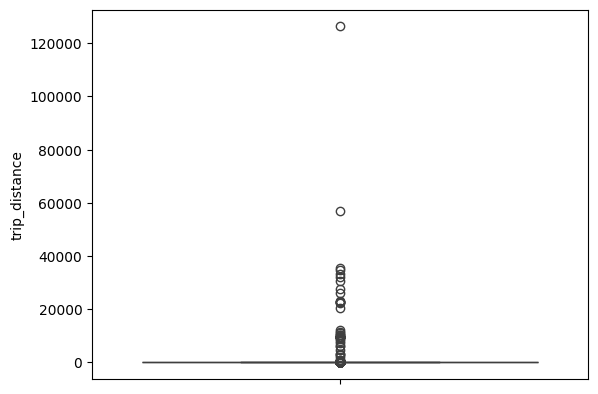

In [28]:
sns.boxplot(df['trip_distance'])

<Axes: ylabel='fare_amount'>

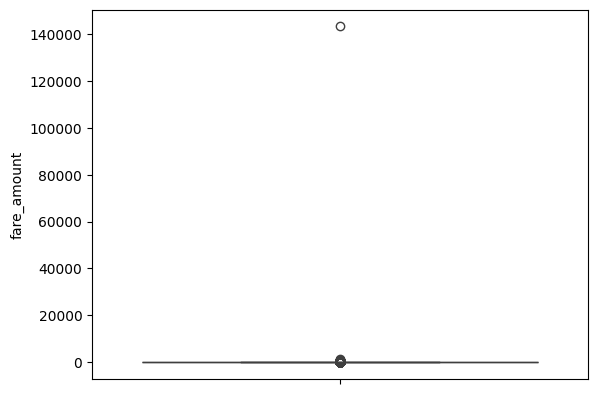

In [29]:
sns.boxplot(df['fare_amount'])

In [30]:
# Continue with outlier handling

# Remove entries where trip_distance is very small (e.g., < 0.1) but fare_amount is very high (>300)
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

print(f"Number of rows after removing (trip_distance < 0.1 and fare_amount > 300) outliers: {len(df)}")

Number of rows after removing (trip_distance < 0.1 and fare_amount > 300) outliers: 1896344


In [31]:
# Remove entries where trip_distance and fare_amount are 0, but pickup and dropoff zones are different
# This implies an illogical trip and should be considered an outlier.
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

print(f"Number of rows after removing (trip_distance=0, fare_amount=0, but different zones) outliers: {len(df)}")

Number of rows after removing (trip_distance=0, fare_amount=0, but different zones) outliers: 1896281


Let's remove trips with excessively long `trip_distance` (e.g., more than 250 miles) as these are likely outliers or data entry errors.

In [32]:
df = df[df['trip_distance'] <= 250]
print(f"Number of rows after removing trip_distance > 250 miles outliers: {len(df)}")

Number of rows after removing trip_distance > 250 miles outliers: 1896235


<Axes: ylabel='trip_distance'>

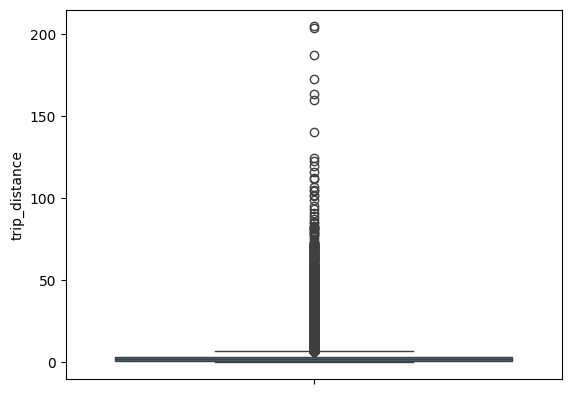

In [33]:
sns.boxplot(df['trip_distance'])

Next, let's address entries where `payment_type` is 0, as this value is not defined in the data dictionary and likely represents an error.

In [34]:
df = df[df['payment_type'] != 0]
print(f"Number of rows after removing payment_type = 0: {len(df)}")

Number of rows after removing payment_type = 0: 1831391


Let's check the distribution of `fare_amount` again and remove any remaining extreme outliers, particularly those with excessively high values.

In [35]:
df = df[df['fare_amount'] <= 10000]
print(f"Number of rows after removing fare_amount > $10,000 outliers: {len(df)}")

Number of rows after removing fare_amount > $10,000 outliers: 1831390


In [36]:
num_cols = df.select_dtypes(include= 'number').columns

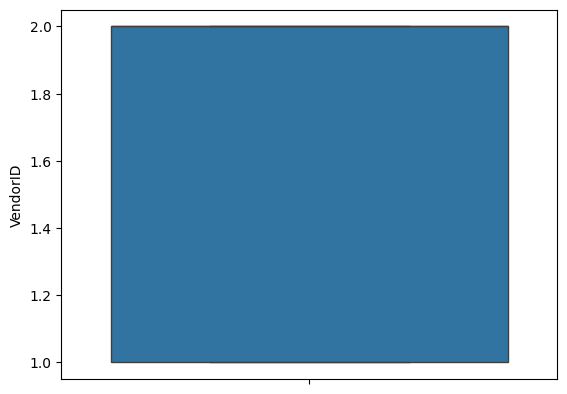

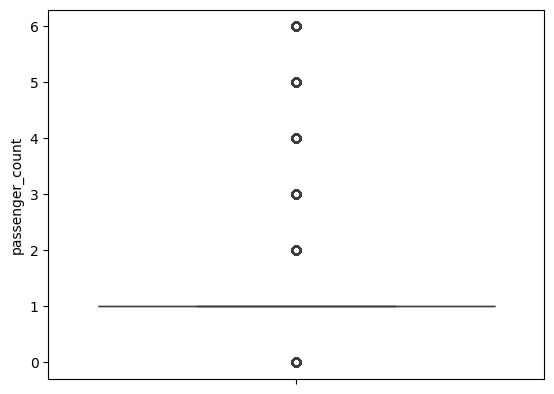

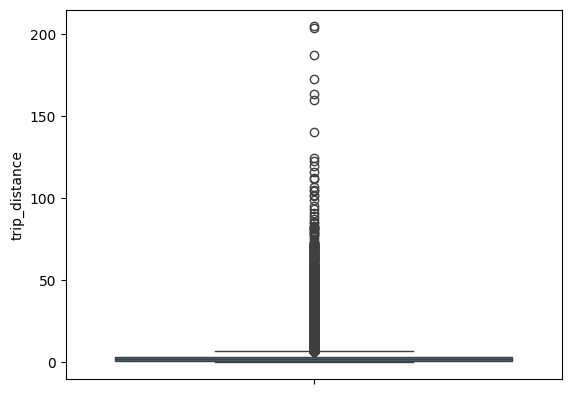

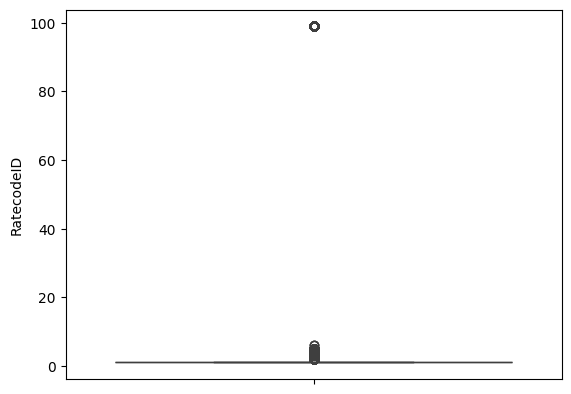

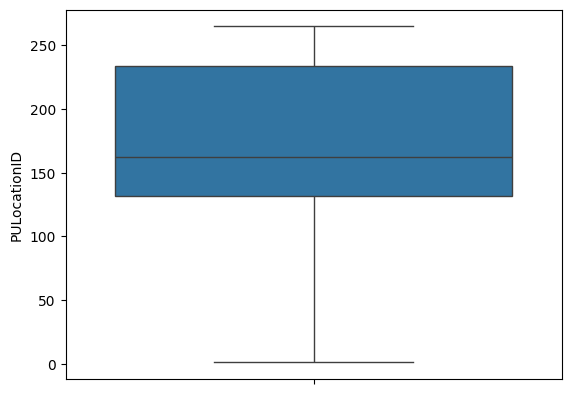

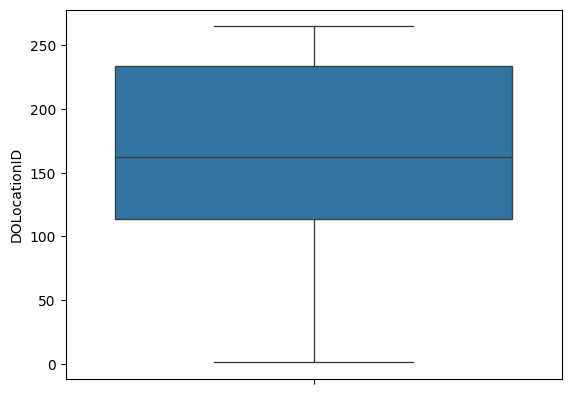

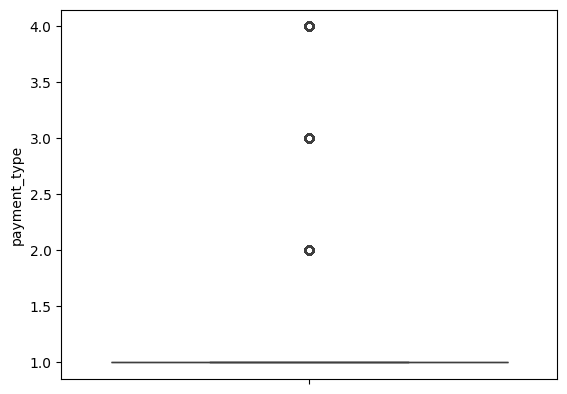

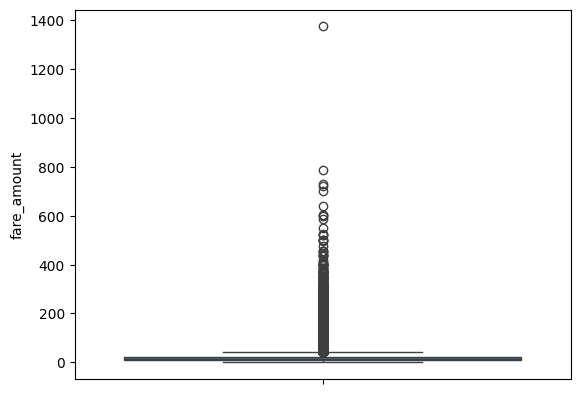

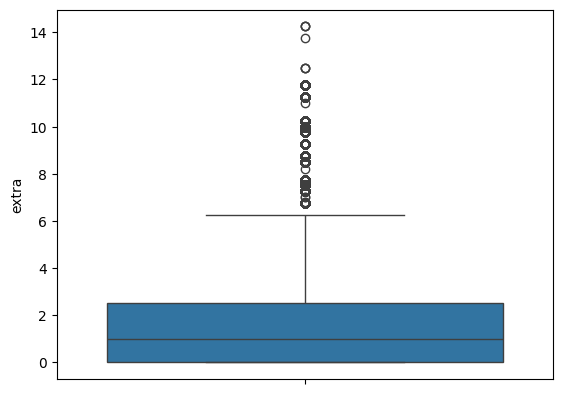

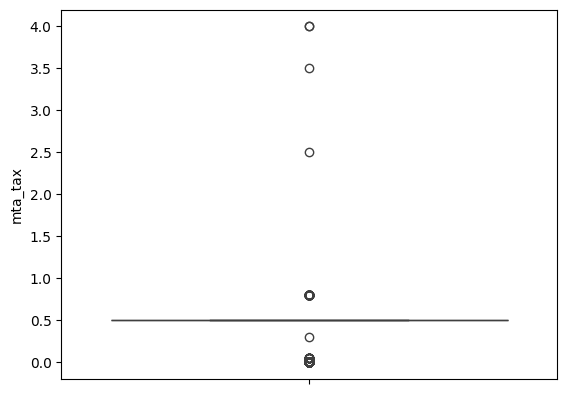

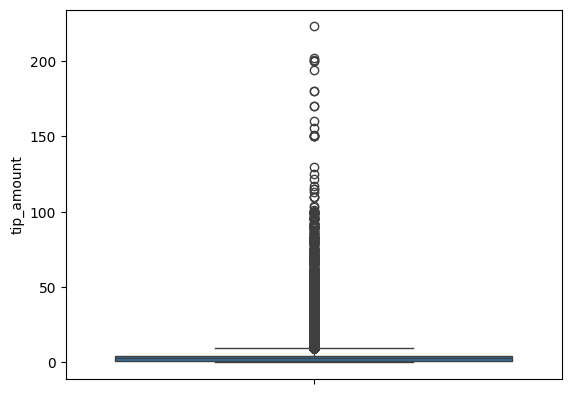

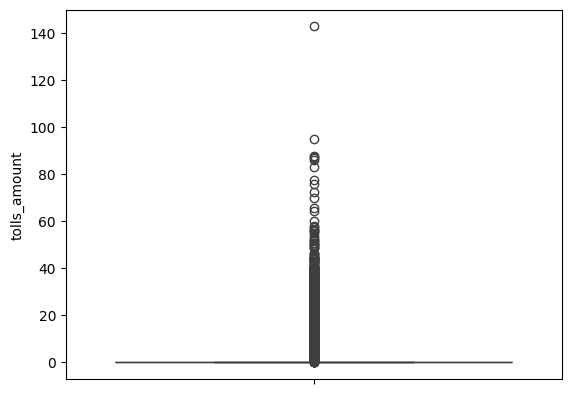

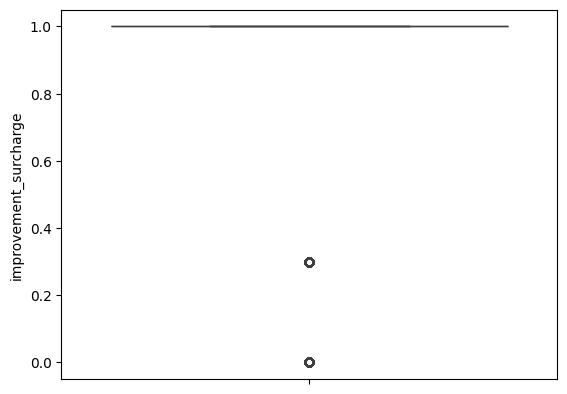

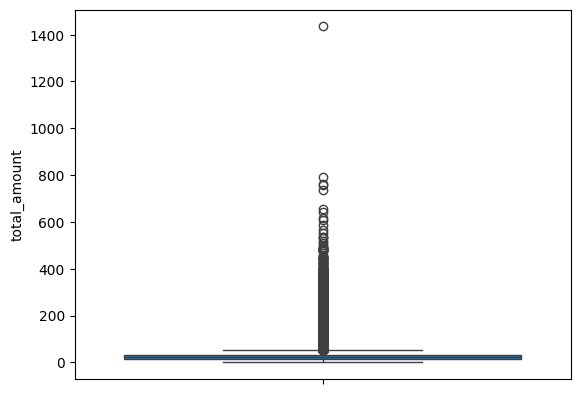

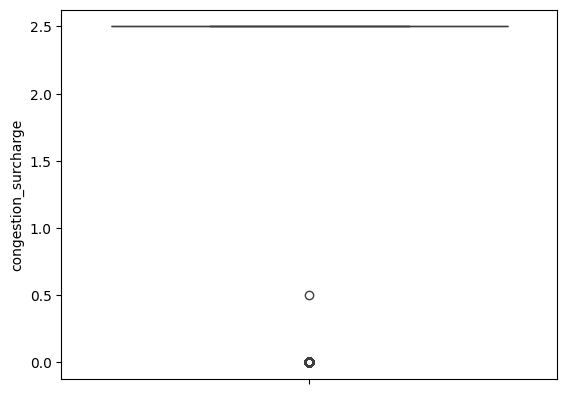

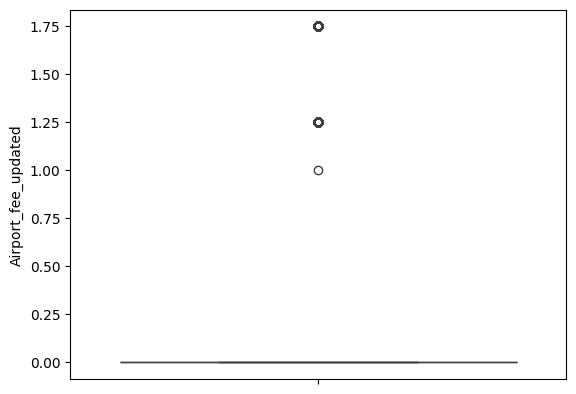

In [37]:
for col in num_cols:
  sns.boxplot(df[col])
  plt.show()

In [38]:
print(df['RatecodeID'].value_counts())
print(df['RatecodeID'].describe())

RatecodeID
1.0     1729208
2.0       71667
99.0      10462
5.0       10203
3.0        6124
4.0        3723
6.0           3
Name: count, dtype: int64
count    1.831390e+06
mean     1.634047e+00
std      7.390657e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.900000e+01
Name: RatecodeID, dtype: float64


In [39]:
# Replace invalid RatecodeID values with the mode
# Valid RatecodeIDs are 1 through 6

valid_ratecode_ids = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
ratecode_id_mode = df['RatecodeID'].mode()[0]

df['RatecodeID'] = df['RatecodeID'].apply(lambda x: x if x in valid_ratecode_ids else ratecode_id_mode)

print(f"Unique values in 'RatecodeID' after cleaning: {df['RatecodeID'].unique()}")
print(f"Mode of 'RatecodeID' after cleaning: {df['RatecodeID'].mode()[0]}")

Unique values in 'RatecodeID' after cleaning: [1. 2. 4. 5. 3. 6.]
Mode of 'RatecodeID' after cleaning: 1.0


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [40]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee_updated']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: 'Numerical'
* `tpep_pickup_datetime`: "DateTime"
* `tpep_dropoff_datetime`:"DateTime"
* `passenger_count`: 'Numerical'
* `trip_distance`: 'Numerical'
* `RatecodeID`: 'Categorical'
* `PULocationID`: 'Categorical'
* `DOLocationID`: 'Categorical'
* `payment_type`: 'Categorical'
* `pickup_hour`: 'Numerical'
* `trip_duration`: 'Numerical'


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount` : 'Numerical'
* `extra` : 'Numerical'
* `mta_tax` : 'Numerical'
* `tip_amount` : 'Numerical'
* `tolls_amount` : 'Numerical'
* `improvement_surcharge` : 'Numerical'
* `total_amount` : 'Numerical'
* `congestion_surcharge` : 'Numerical'
* `airport_fee` : 'Numerical'

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [41]:
# Find and show the hourly trends in taxi pickups



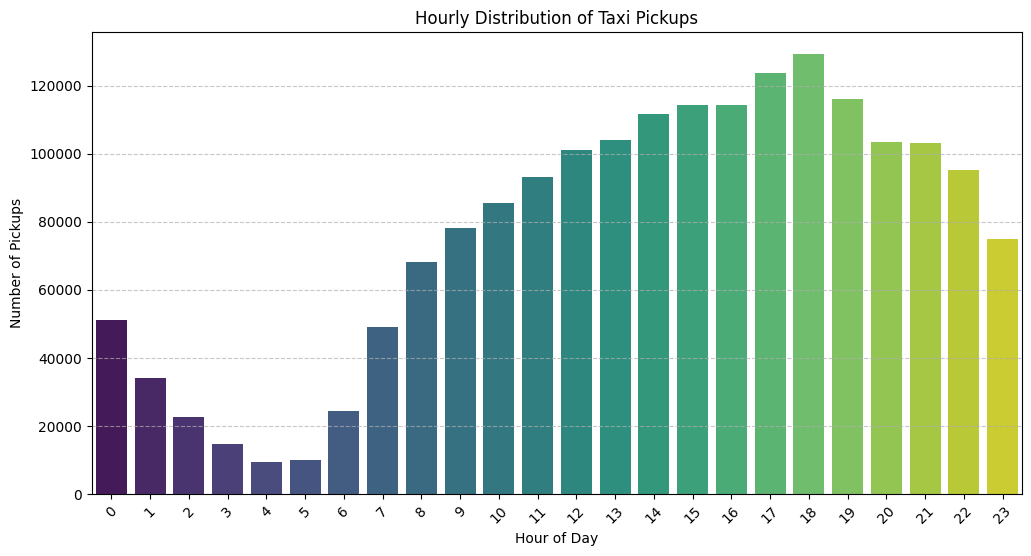

In [42]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_pickups = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis')
plt.title('Hourly Distribution of Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [43]:
# Find and show the daily trends in taxi pickups (days of the week)



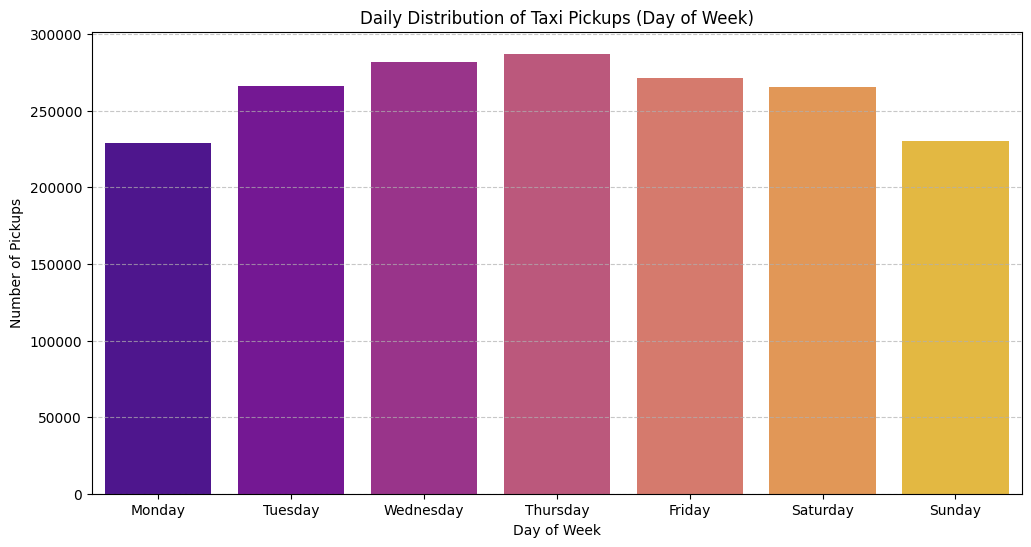

In [44]:
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek # Monday=0, Sunday=6
daily_pickups = df['pickup_day_of_week'].value_counts().sort_index()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 6))
sns.barplot(x=[day_names[day] for day in daily_pickups.index], y=daily_pickups.values, palette='plasma')
plt.title('Daily Distribution of Taxi Pickups (Day of Week)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [45]:
# Show the monthly trends in pickups



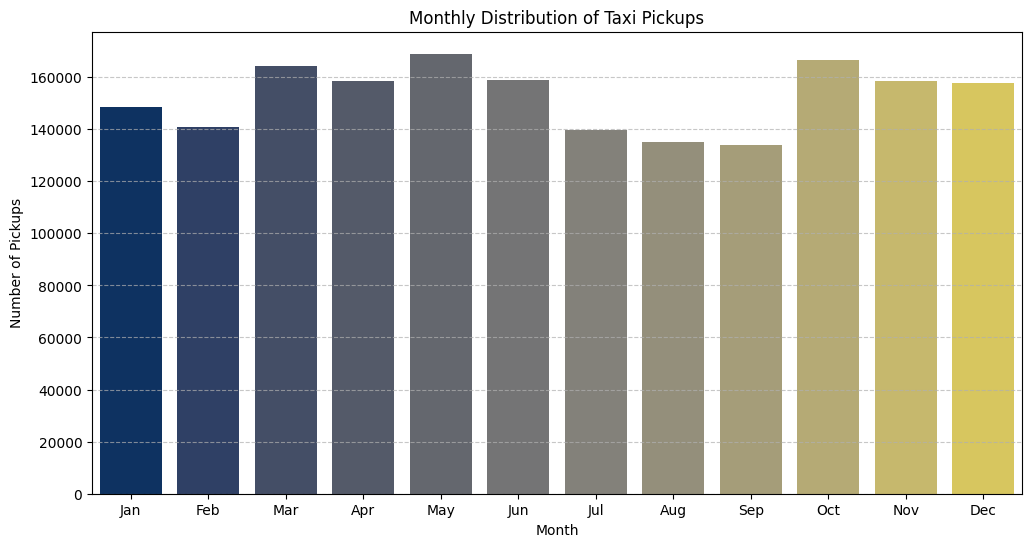

In [46]:
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
monthly_pickups = df['pickup_month'].value_counts().sort_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.barplot(x=[month_names[month-1] for month in monthly_pickups.index], y=monthly_pickups.values, palette='cividis')
plt.title('Monthly Distribution of Taxi Pickups')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [47]:
print('Number of zero values:')
print(df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']][(df['fare_amount'] == 0) | (df['tip_amount'] == 0) | (df['total_amount'] == 0) | (df['trip_distance'] == 0)].sum())

print('\nPercentage of zero values:')
for col in ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']:
    zero_count = (df[col] == 0).sum()
    total_count = len(df)
    percentage = (zero_count / total_count) * 100
    print(f"{col}: {zero_count} ({percentage:.2f}%)")

Number of zero values:
fare_amount       8799235.50
tip_amount          70503.96
total_amount     11066211.62
trip_distance     1476096.26
dtype: float64

Percentage of zero values:
fare_amount: 575 (0.03%)
tip_amount: 410233 (22.40%)
total_amount: 329 (0.02%)
trip_distance: 22928 (1.25%)


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [48]:
# Create a df with non zero entries for the selected parameters.
# Creating a new DataFrame to analyze financial metrics without zero values allows for more accurate statistical analysis
# and visualization of actual revenue-generating trips. This prevents distortion of averages and distributions.
df_financial = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0) & (df['total_amount'] > 0) & (df['trip_distance'] > 0)].copy()
display(df_financial.head())
print(f"Original DataFrame rows: {len(df)}")
print(f"Financial DataFrame rows (excluding zero fare/distance): {len(df_financial)}")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee_updated,pickup_hour,pickup_day_of_week,pickup_month
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.5,0.00,0.00,1.0,10.10,2.5,0.00,0,4,9
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,0.5,15.71,6.94,1.0,98.40,2.5,1.75,0,4,9
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.5,0.00,0.00,1.0,64.70,2.5,0.00,0,4,9
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.5,2.00,0.00,1.0,14.90,2.5,0.00,0,4,9
5,2,2023-09-01 00:41:08,2023-09-01 00:54:33,5.0,4.39,1.0,N,79,263,1,...,0.5,4.82,0.00,1.0,28.92,2.5,0.00,0,4,9


Original DataFrame rows: 1831390
Financial DataFrame rows (excluding zero fare/distance): 1808146


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

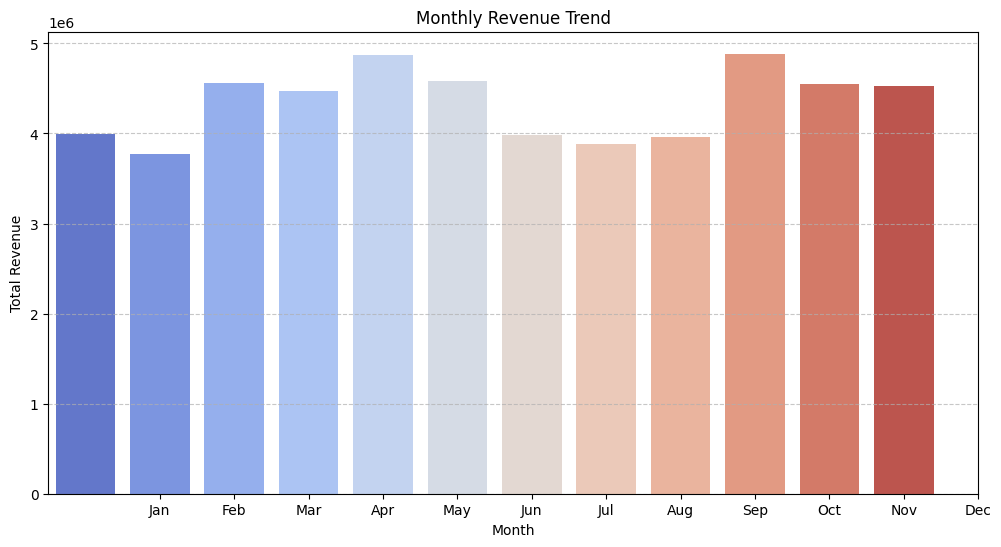

In [49]:
# Group data by month and analyse monthly revenue
df_financial['pickup_month'] = df_financial['tpep_pickup_datetime'].dt.month
monthly_revenue = df_financial.groupby('pickup_month')['total_amount'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='coolwarm')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

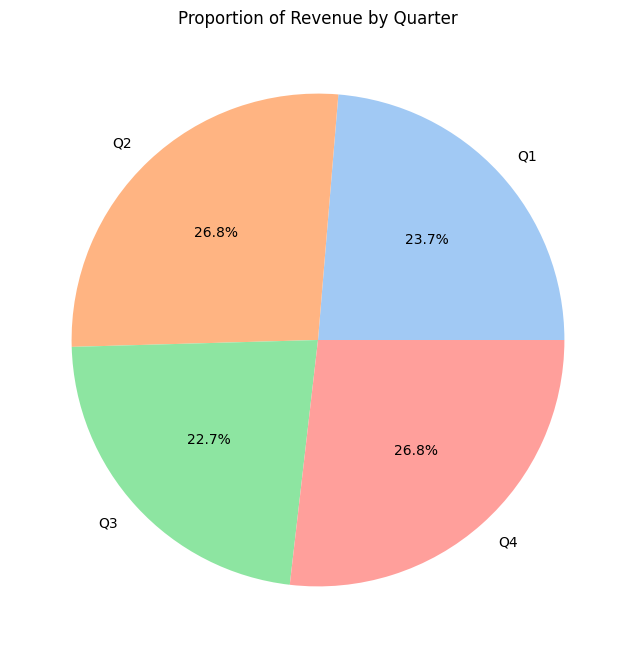

In [50]:
# Calculate proportion of each quarter
df_financial['pickup_quarter'] = df_financial['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df_financial.groupby('pickup_quarter')['total_amount'].sum()

plt.figure(figsize=(8, 8))
plt.pie(quarterly_revenue, labels=[f'Q{q}' for q in quarterly_revenue.index], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proportion of Revenue by Quarter')
plt.ylabel('') # Hide the default y-label for pie chart
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

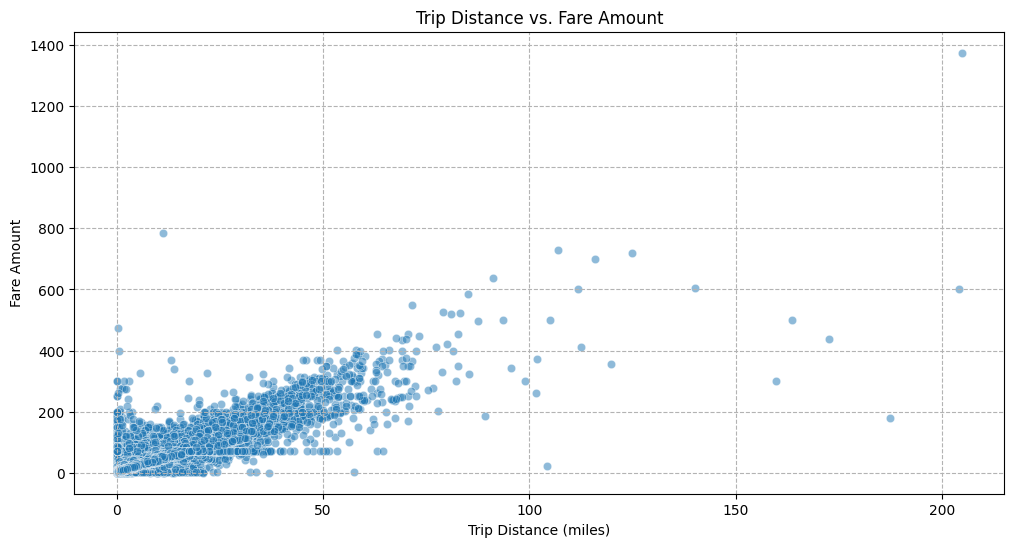

Correlation between trip_distance and fare_amount: 0.94


In [51]:
# Remove trips with zero distance to avoid division by zero or misleading correlations
df_filtered_distance = df_financial[df_financial['trip_distance'] > 0]

plt.figure(figsize=(12, 6))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_filtered_distance, alpha=0.5)
plt.title('Trip Distance vs. Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

correlation = df_filtered_distance['trip_distance'].corr(df_filtered_distance['fare_amount'])
print(f"Correlation between trip_distance and fare_amount: {correlation:.2f}")

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

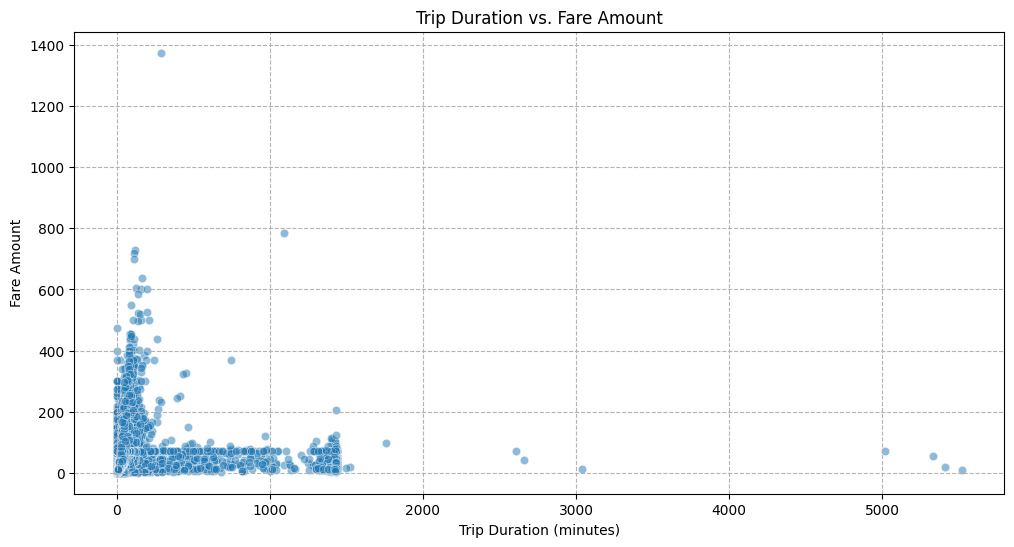

Correlation between fare_amount and trip_duration: 0.28


In [52]:
# Calculate trip duration in minutes
df_financial['trip_duration'] = (df_financial['tpep_dropoff_datetime'] - df_financial['tpep_pickup_datetime']).dt.total_seconds() / 60

plt.figure(figsize=(12, 6))
sns.scatterplot(x='trip_duration', y='fare_amount', data=df_financial[df_financial['trip_duration'] > 0], alpha=0.5)
plt.title('Trip Duration vs. Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

correlation_fare_duration = df_financial['trip_duration'].corr(df_financial['fare_amount'])
print(f"Correlation between fare_amount and trip_duration: {correlation_fare_duration:.2f}")

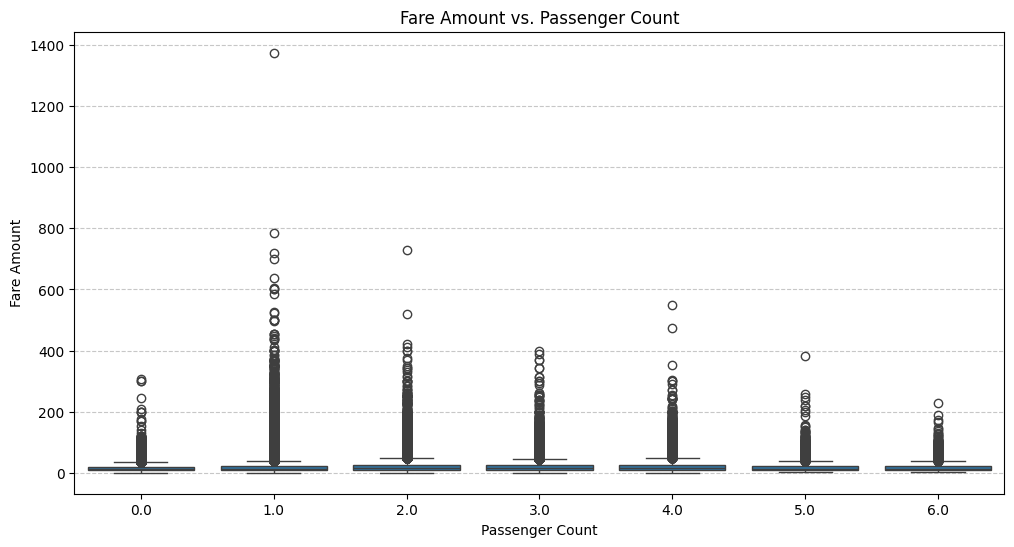

Correlation between fare_amount and passenger_count: 0.04


In [53]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='passenger_count', y='fare_amount', data=df_financial)
plt.title('Fare Amount vs. Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

correlation_fare_passenger = df_financial['passenger_count'].corr(df_financial['fare_amount'])
print(f"Correlation between fare_amount and passenger_count: {correlation_fare_passenger:.2f}")

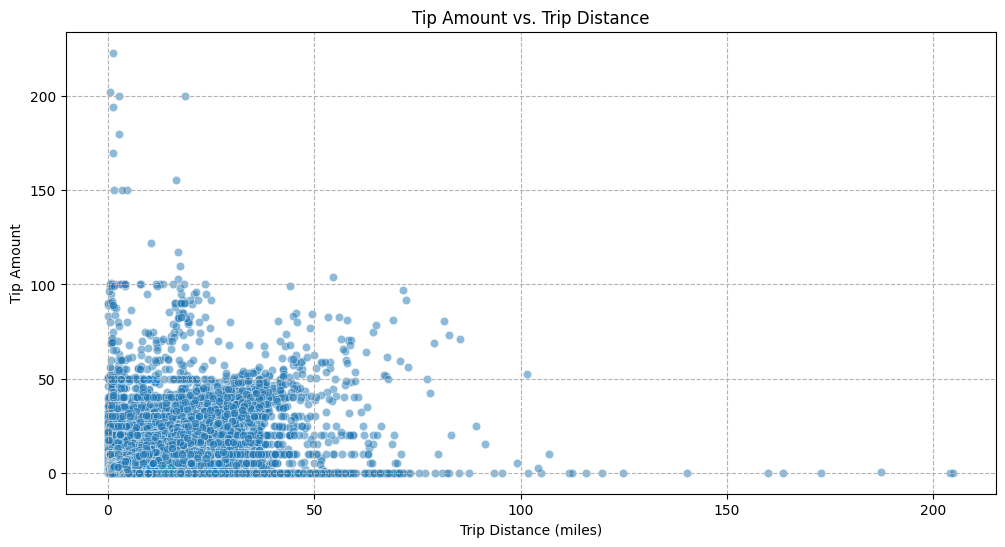

Correlation between tip_amount and trip_distance: 0.59


In [54]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_financial[df_financial['trip_distance'] > 0], alpha=0.5)
plt.title('Tip Amount vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

correlation_tip_distance = df_financial['trip_distance'].corr(df_financial['tip_amount'])
print(f"Correlation between tip_amount and trip_distance: {correlation_tip_distance:.2f}")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

Distribution of Payment Types:
payment_type
1    1492301
2     316411
4      13672
3       9006
Name: count, dtype: int64

Percentage Distribution of Payment Types:
payment_type
1    81.484610
2    17.277096
4     0.746537
3     0.491758
Name: proportion, dtype: float64


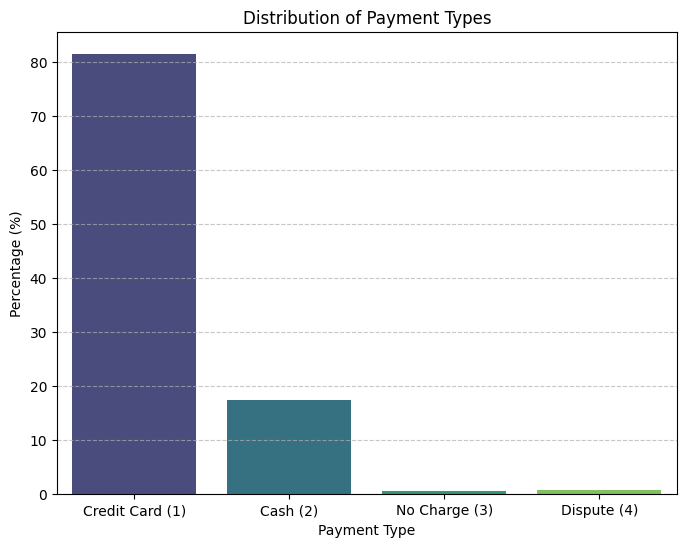

In [55]:
# Analyse the distribution of different payment types (payment_type).
payment_type_counts = df['payment_type'].value_counts()
payment_type_percentages = df['payment_type'].value_counts(normalize=True) * 100

print("Distribution of Payment Types:")
print(payment_type_counts)
print("\nPercentage Distribution of Payment Types:")
print(payment_type_percentages)

plt.figure(figsize=(8, 6))
sns.barplot(x=payment_type_percentages.index, y=payment_type_percentages.values, palette='viridis')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Credit Card (1)', 'Cash (2)', 'No Charge (3)', 'Dispute (4)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [56]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [57]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('/content/drive/MyDrive/Datasets and Dictionary/taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

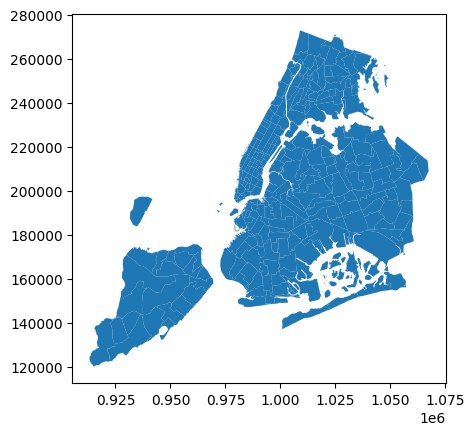

In [58]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [59]:
# Merge zones and trip records using locationID and PULocationID
df_with_zones = pd.merge(df_financial, zones, left_on='PULocationID', right_on='LocationID', how='left')
df_with_zones.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_month,pickup_quarter,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,9,3,2.483333,142.0,0.038176,0.000076,Lincoln Square East,142.0,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21..."
1,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,9,3,44.583333,132.0,0.245479,0.002038,JFK Airport,132.0,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283..."
2,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,9,3,38.116667,249.0,0.036384,0.000072,West Village,249.0,Manhattan,"POLYGON ((983555.319 204876.901, 983469.158 20..."
3,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,9,3,6.300000,144.0,0.027620,0.000047,Little Italy/NoLiTa,144.0,Manhattan,"POLYGON ((985411.76 200369.518, 985342.573 200..."
4,2,2023-09-01 00:41:08,2023-09-01 00:54:33,5.0,4.39,1.0,N,79,263,1,...,9,3,13.416667,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."


In [60]:
df_with_zones.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee_updated',
       'pickup_hour', 'pickup_day_of_week', 'pickup_month', 'pickup_quarter',
       'trip_duration', 'OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone',
       'LocationID', 'borough', 'geometry'],
      dtype='object')

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [61]:
# Group data by location and calculate the number of trips
df_with_zones.groupby('LocationID').size().reset_index(name='trip_count')
trips_per_zone = df_with_zones.groupby('LocationID').size().reset_index(name='trip_count')
trips_per_zone.head()


,LocationID,trip_count
0,1.0,47
1,2.0,2
2,3.0,31
3,4.0,1814
4,5.0,9


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [62]:
zones

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ..."
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ..."
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19..."
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824...."


In [63]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = pd.merge(zones, trips_per_zone, left_on='LocationID', right_on='LocationID', how='left')
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0) # Fill NaN for zones with no pickups
zones_with_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",47.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",31.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1814.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",9.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

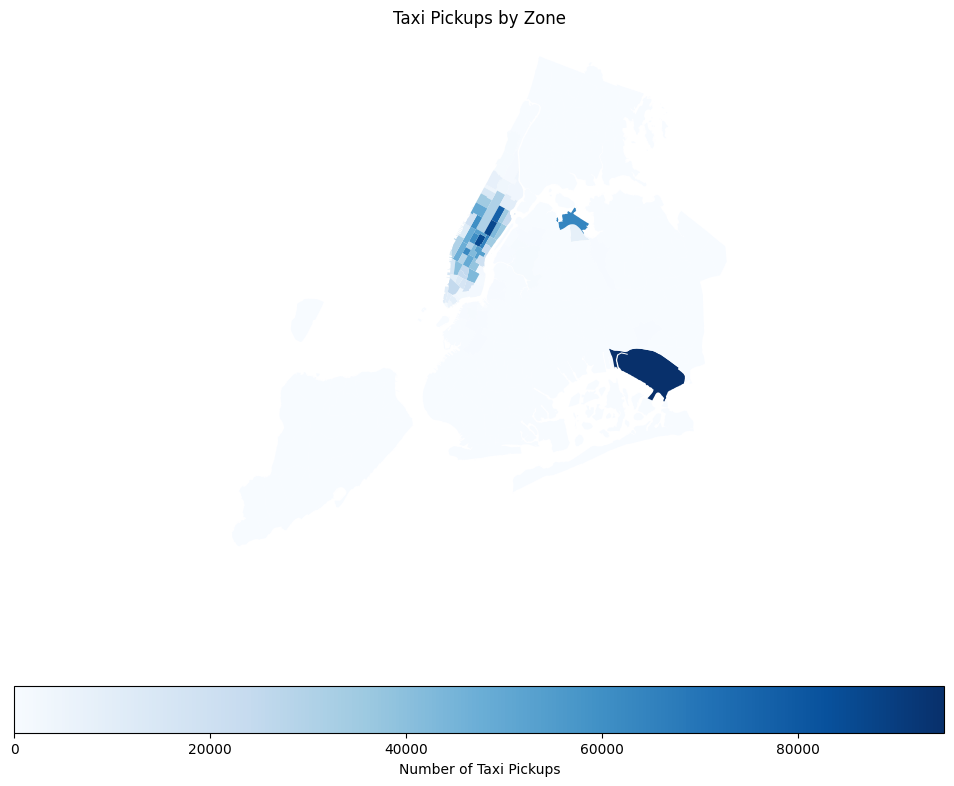

In [64]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones_with_trips.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    cmap='Blues', # Choose a colormap
    legend_kwds={'label': 'Number of Taxi Pickups', 'orientation': 'horizontal'}
)
ax.set_title('Taxi Pickups by Zone')
ax.set_axis_off() # Hide axes for a cleaner map
plt.show()

In [65]:
# Display the zones DataFrame sorted by the number of trips
sorted_zones_by_trips = zones_with_trips.sort_values(by='trip_count', ascending=False)
display(sorted_zones_by_trips.head(10))
display(sorted_zones_by_trips.tail(10))

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",94944.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",86474.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",85401.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",77120.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",65211.0
137,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",63682.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",62990.0
229,230,0.031028,0.000056,Times Sq/Theatre District,230,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",60729.0
141,142,0.038176,0.000076,Lincoln Square East,142,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21...",60507.0
169,170,0.045769,0.000074,Murray Hill,170,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21...",54035.0


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
102,103,0.014306,0.000006,Governor's Island/Ellis Island/Liberty Island,103,Manhattan,"POLYGON ((972079.575 190732.429, 972184.766 19...",0.0
175,176,0.151995,0.000658,Oakwood,176,Staten Island,"POLYGON ((950393.94 148827.195, 950393.983 148...",0.0
109,110,0.103946,0.000526,Great Kills Park,110,Staten Island,"POLYGON ((951420.092 139894.411, 951856.209 13...",0.0
108,109,0.178268,0.001170,Great Kills,109,Staten Island,"POLYGON ((943392.585 147162.426, 943412.636 14...",0.0
104,105,0.077425,0.000369,Governor's Island/Ellis Island/Liberty Island,103,Manhattan,"POLYGON ((979605.759 191880.575, 979978.435 19...",0.0
103,104,0.021221,0.000012,Governor's Island/Ellis Island/Liberty Island,103,Manhattan,"POLYGON ((973172.666 194632.348, 973310.63 194...",0.0
220,221,0.166218,0.000890,Stapleton,221,Staten Island,"POLYGON ((963349.728 171627.581, 963397.759 17...",0.0
98,99,0.183371,0.001210,Freshkills Park,99,Staten Island,"POLYGON ((937468.341 152998.406, 937320.263 15...",0.0
29,30,0.094510,0.000146,Broad Channel,30,Queens,"POLYGON ((1034013.272 163473.152, 1034866.459 ...",0.0
244,245,0.095983,0.000466,West Brighton,245,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",0.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
By the Hour: Most folks are jumping in cabs in the afternoon and evening. Peak time is usually between 5 PM and 7 PM. Sounds like the rush hour crowd and folks heading out for dinner or whatever.
By the Day: Weekdays are where it's at for taxi business, especially Tuesday through Friday. Wednesday and Thursday seem to be the busiest. Weekends are a bit more chill.
By the Month: Pretty consistent throughout the year, actually. There are minor bumps and dips, probably 'cause of holidays or big events, but no wild swings.

* Trends in revenue collected: The cash flow each month ain't perfectly flat; it goes up and down a bit. This could be due to seasonal stuff or big happenings in the city.

* Trends in quarterly revenue:When you break it down by quarters, the revenue is pretty evenly spread out. No single quarter is wildly outperforming the others, but there are small differences.

* How fare depends on trip distance, trip duration and passenger counts

Fare vs. Trip Duration: How long you're in the cab also plays a role in the fare, but not as much as the distance (a 0.28 correlation). Time is money, but distance is more money!
Fare vs. Passenger Count: This is interesting: the number of people in the taxi barely affects the fare (just a tiny 0.04 correlation). So, whether it's one person or a whole crew, the fare stays pretty much the same.

* How tip amount depends on trip distance
Tip vs. Trip Distance: Longer trips tend to bring in bigger tips (a 0.59 correlation). Makes sense; if you're taking a long ride, you might be feeling more generous, or the total fare is higher, so a percentage tip is bigger.

* Busiest zones
The real hustling and bustling areas for pickups are places like JFK Airport, Upper East Side South, Midtown Center, Midtown East, and LaGuardia Airport. These are definitely prime locations.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [66]:
df_financial.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee_updated',
       'pickup_hour', 'pickup_day_of_week', 'pickup_month', 'pickup_quarter',
       'trip_duration'],
      dtype='object')

In [67]:
# Find routes which have the slowest speeds at different times of the day



In [68]:
df_financial['route'] = df_financial['PULocationID'].astype(str) + '-' + df_financial['DOLocationID'].astype(str)

# Filter out trips with non-positive trip duration before calculating speeds
df_filtered_for_speed = df_financial[df_financial['trip_duration'] > 0].copy()

# Group by route and pickup hour to calculate average trip distance and duration
route_hourly_stats = df_filtered_for_speed.groupby(['route', 'pickup_hour']).agg(
    average_trip_distance=('trip_distance', 'mean'),
    average_trip_duration=('trip_duration', 'mean')
).reset_index()

# Calculate average speed (handling cases where duration might be 0 to avoid division by zero)
route_hourly_stats['average_speed_mph'] = route_hourly_stats.apply(
    lambda row: row['average_trip_distance'] / (row['average_trip_duration'] / 60) if row['average_trip_duration'] > 0 else 0,
    axis=1
)

# Sort to find the slowest routes
slowest_routes = route_hourly_stats.sort_values(by='average_speed_mph').head(10)

print("Top 10 Slowest Routes by Average Speed (MPH):")
display(slowest_routes)

Top 10 Slowest Routes by Average Speed (MPH):


,route,pickup_hour,average_trip_distance,average_trip_duration,average_speed_mph
72200,232-65,13,0.490000,5522.433333,0.005324
84999,243-264,17,0.180000,1389.550000,0.007772
29573,142-142,5,0.560000,1413.550000,0.023770
90949,258-258,1,0.020000,45.750000,0.026230
2361,100-7,8,0.220000,334.433333,0.039470
99828,40-65,21,1.120000,1434.433333,0.046848
6031,113-235,22,0.280000,349.233333,0.048105
58345,194-194,16,0.010000,12.266667,0.048913
64325,226-145,18,1.563333,1810.761111,0.051801
103730,45-45,10,0.050000,50.433333,0.059484


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [69]:
# Visualise the number of trips per hour and find the busiest hour



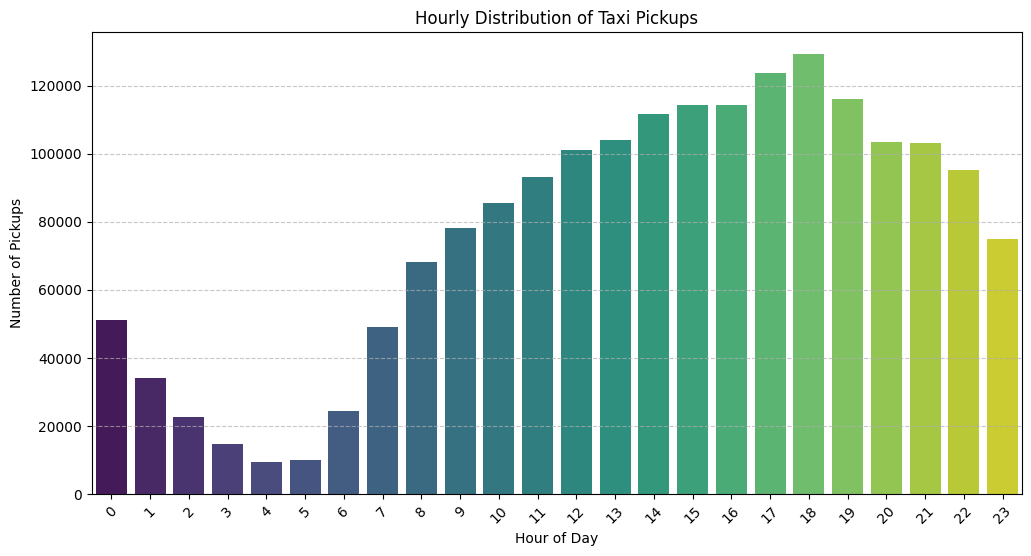

The busiest hour of the day is 18:00 with 129190 trips.


In [70]:
# Calculate hourly pickups (if not already calculated)
# df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
# hourly_pickups = df['pickup_hour'].value_counts().sort_index()

# The hourly_pickups Series should already be available from a previous cell.
# If not, uncomment the lines above.

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis')
plt.title('Hourly Distribution of Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

busiest_hour = hourly_pickups.idxmax()
busiest_hour_trips = hourly_pickups.max()

print(f"The busiest hour of the day is {busiest_hour}:00 with {busiest_hour_trips} trips.")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [71]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

# Get the top 5 busiest hours from the hourly_pickups Series
busiest_5_hours = hourly_pickups.nlargest(5)

# Scale up the counts by dividing by the sample_fraction
actual_busiest_5_hours = busiest_5_hours / sample_fraction

print("Actual number of trips for the five busiest hours:")
print(actual_busiest_5_hours)


Actual number of trips for the five busiest hours:
pickup_hour
18    2583800.0
17    2471260.0
19    2318400.0
15    2286020.0
16    2285780.0
Name: count, dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [72]:
# Compare traffic trends for the week days and weekends



Top 10 Pickup Zones (IDs): [132, 237, 161, 236, 162, 138, 186, 230, 142, 170]
Top 10 Pickup Zones (Names): ['JFK Airport', 'LaGuardia Airport', 'Lincoln Square East', 'Midtown Center', 'Midtown East', 'Murray Hill', 'Penn Station/Madison Sq West', 'Times Sq/Theatre District', 'Upper East Side North', 'Upper East Side South']
Top 10 Dropoff Zones (IDs): [236, 237, 161, 230, 170, 162, 142, 239, 141, 68]
Top 10 Dropoff Zones (Names): ['East Chelsea', 'Lenox Hill West', 'Lincoln Square East', 'Midtown Center', 'Midtown East', 'Murray Hill', 'Times Sq/Theatre District', 'Upper East Side North', 'Upper East Side South', 'Upper West Side South']


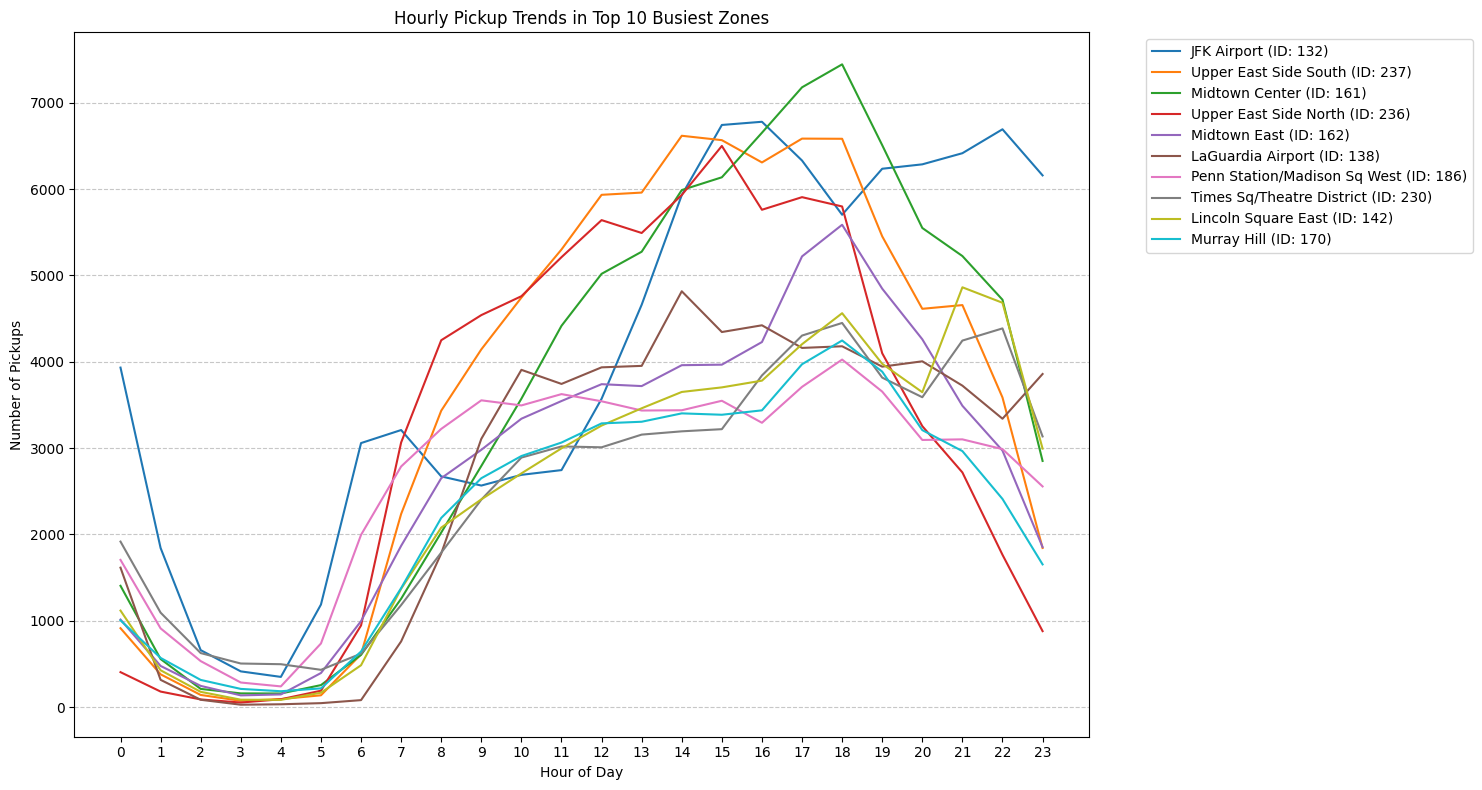

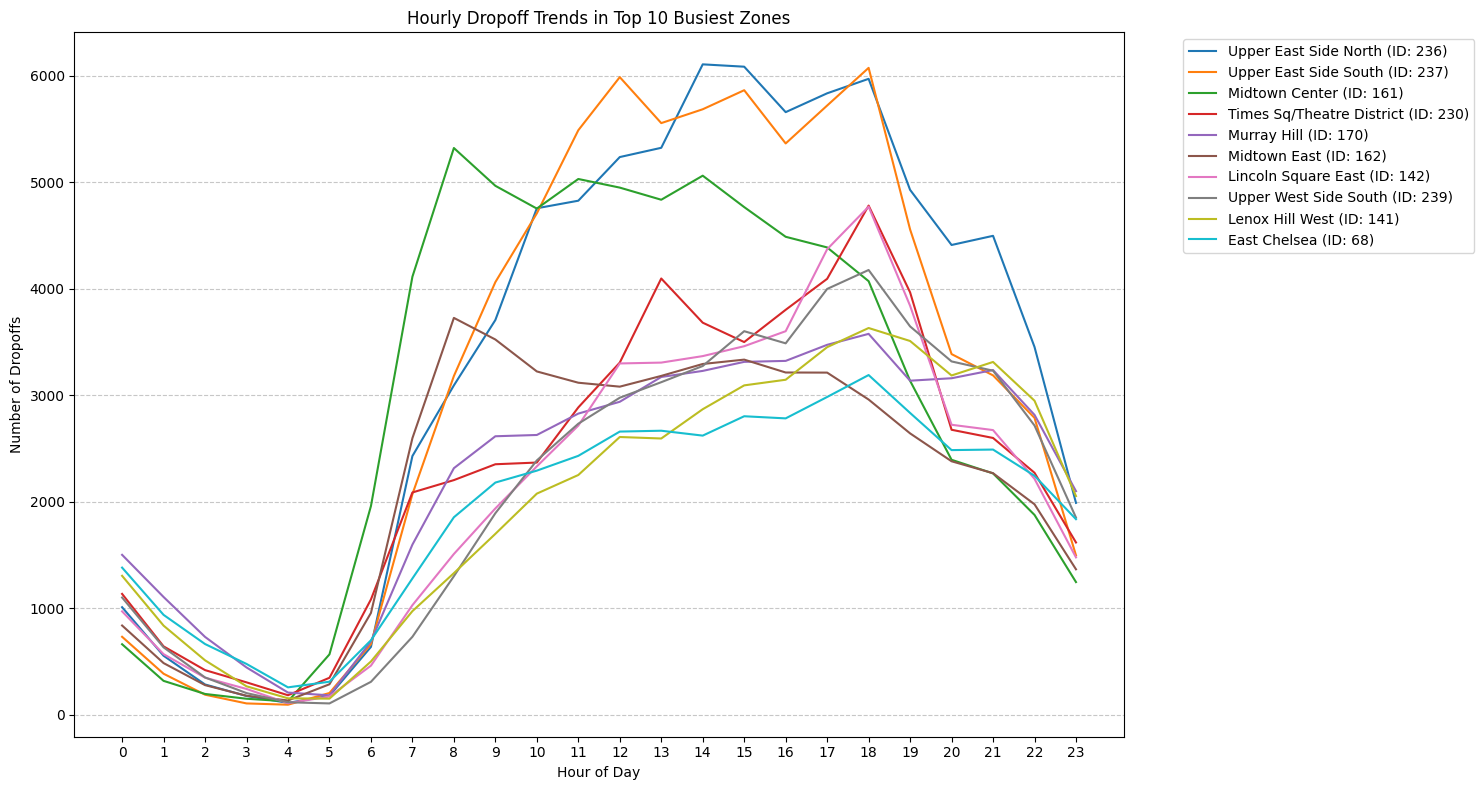

In [73]:
# Calculate total pickups per zone using the original df (not df_financial for general trends)
pickup_counts = df['PULocationID'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'pickup_count']

# Calculate total dropoffs per zone
dropoff_counts = df['DOLocationID'].value_counts().reset_index()
dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Get top 10 pickup zones
top_10_pickup_zones_ids = pickup_counts.nlargest(10, 'pickup_count')['LocationID'].tolist()
top_10_pickup_zones_names = zones[zones['LocationID'].isin(top_10_pickup_zones_ids)]['zone'].tolist()
print(f"Top 10 Pickup Zones (IDs): {top_10_pickup_zones_ids}")
print(f"Top 10 Pickup Zones (Names): {top_10_pickup_zones_names}")

# Get top 10 dropoff zones
top_10_dropoff_zones_ids = dropoff_counts.nlargest(10, 'dropoff_count')['LocationID'].tolist()
top_10_dropoff_zones_names = zones[zones['LocationID'].isin(top_10_dropoff_zones_ids)]['zone'].tolist()
print(f"Top 10 Dropoff Zones (IDs): {top_10_dropoff_zones_ids}")
print(f"Top 10 Dropoff Zones (Names): {top_10_dropoff_zones_names}")

# Hourly trends for top 10 pickup zones
plt.figure(figsize=(15, 8))
for zone_id in top_10_pickup_zones_ids:
    zone_name = zones[zones['LocationID'] == zone_id]['zone'].iloc[0]
    hourly_data = df[df['PULocationID'] == zone_id].groupby('pickup_hour').size()
    sns.lineplot(x=hourly_data.index, y=hourly_data.values, label=f'{zone_name} (ID: {zone_id})')
plt.title('Hourly Pickup Trends in Top 10 Busiest Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# Hourly trends for top 10 dropoff zones
plt.figure(figsize=(15, 8))
for zone_id in top_10_dropoff_zones_ids:
    zone_name = zones[zones['LocationID'] == zone_id]['zone'].iloc[0]
    hourly_data = df[df['DOLocationID'] == zone_id].groupby('pickup_hour').size()
    sns.lineplot(x=hourly_data.index, y=hourly_data.values, label=f'{zone_name} (ID: {zone_id})')
plt.title('Hourly Dropoff Trends in Top 10 Busiest Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Dropoffs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(24))
plt.tight_layout()
plt.show()


<Figure size 1400x700 with 0 Axes>

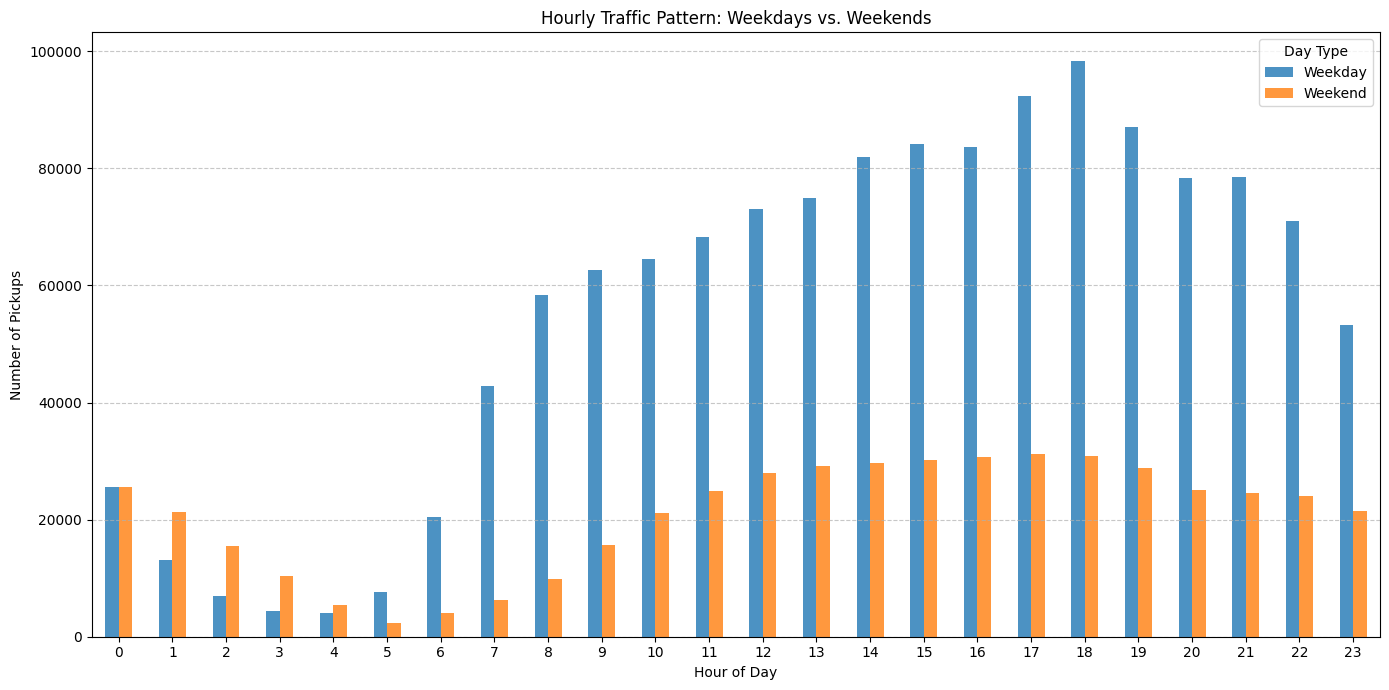

Hourly traffic patterns for weekdays and weekends:


day_type,Weekday,Weekend
pickup_hour,,
0,25593,25571
1,13033,21245
2,7036,15515
3,4370,10340
4,4004,5432
5,7621,2400
6,20488,3980
7,42761,6229
8,58392,9886


In [74]:
# Create a 'day_type' column (Weekday or Weekend)
df['day_type'] = df['tpep_pickup_datetime'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Group by day type and pickup hour
hourly_pickups_by_day_type = df.groupby(['day_type', 'pickup_hour']).size().unstack(level=0)

plt.figure(figsize=(14, 7))
hourly_pickups_by_day_type.plot(kind='bar', figsize=(14, 7), alpha=0.8)
plt.title('Hourly Traffic Pattern: Weekdays vs. Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=0)
plt.legend(title='Day Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Hourly traffic patterns for weekdays and weekends:")
display(hourly_pickups_by_day_type)


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [75]:
# Calculate total pickups per zone
pickup_counts = df['PULocationID'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'pickup_count']

# Calculate total dropoffs per zone
dropoff_counts = df['DOLocationID'].value_counts().reset_index()
dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Get top 10 pickup zones
top_10_pickup_zones = pickup_counts.nlargest(10, 'pickup_count')
top_10_pickup_zones = pd.merge(top_10_pickup_zones, zones[['LocationID', 'zone']], on='LocationID', how='left')

print("Top 10 Pickup Zones:")
display(top_10_pickup_zones)

# Get top 10 dropoff zones
top_10_dropoff_zones = dropoff_counts.nlargest(10, 'dropoff_count')
top_10_dropoff_zones = pd.merge(top_10_dropoff_zones, zones[['LocationID', 'zone']], on='LocationID', how='left')

print("\nTop 10 Dropoff Zones:")
display(top_10_dropoff_zones)

Top 10 Pickup Zones:


,LocationID,pickup_count,zone
0,132,96827,JFK Airport
1,237,86905,Upper East Side South
2,161,85948,Midtown Center
3,236,77517,Upper East Side North
4,162,65634,Midtown East
5,138,64177,LaGuardia Airport
6,186,63471,Penn Station/Madison Sq West
7,230,61315,Times Sq/Theatre District
8,142,60887,Lincoln Square East
9,170,54493,Murray Hill



Top 10 Dropoff Zones:


,LocationID,dropoff_count,zone
0,236,81269,Upper East Side North
1,237,77558,Upper East Side South
2,161,71647,Midtown Center
3,230,56398,Times Sq/Theatre District
4,170,54314,Murray Hill
5,162,52248,Midtown East
6,142,51494,Lincoln Square East
7,239,51260,Upper West Side South
8,141,48449,Lenox Hill West
9,68,46352,East Chelsea


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Calculate total pickups per zone
pickup_counts = df_financial['PULocationID'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'pickup_count']

# Calculate total dropoffs per zone
dropoff_counts = df_financial['DOLocationID'].value_counts().reset_index()
dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Merge pickup and dropoff counts
zone_traffic = pd.merge(pickup_counts, dropoff_counts, on='LocationID', how='outer').fillna(0)

# Calculate Pickup/Dropoff Ratio, handling division by zero
zone_traffic['pickup_dropoff_ratio'] = zone_traffic.apply(
    lambda row: row['pickup_count'] / row['dropoff_count'] if row['dropoff_count'] > 0 else np.inf,
    axis=1
)

# Merge with zones data to get zone names
zone_traffic = pd.merge(zone_traffic, zones[['LocationID', 'zone']], on='LocationID', how='left')

# Sort by ratio to find highest and lowest
highest_ratio_zones = zone_traffic.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
lowest_ratio_zones = zone_traffic.sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)

print("Top 10 Zones with Highest Pickup/Dropoff Ratios (more pickups than dropoffs):")
display(highest_ratio_zones)

print("\nTop 10 Zones with Lowest Pickup/Dropoff Ratios (more dropoffs than pickups):")
display(lowest_ratio_zones)

Top 10 Zones with Highest Pickup/Dropoff Ratios (more pickups than dropoffs):


,LocationID,pickup_count,dropoff_count,pickup_dropoff_ratio,zone
195,199,2.0,0.0,inf,Rikers Island
70,70,8194.0,868.0,9.440092,East Elmhurst
128,132,94944.0,19327.0,4.912506,JFK Airport
134,138,63682.0,21786.0,2.923070,LaGuardia Airport
182,186,62990.0,39758.0,1.584335,Penn Station/Madison Sq West
110,114,23980.0,17427.0,1.376026,Greenwich Village South
42,43,30603.0,22241.0,1.375972,Central Park
245,249,40206.0,30270.0,1.328246,West Village
158,162,65211.0,51854.0,1.257589,Midtown East
157,161,85401.0,71152.0,1.200261,Midtown Center



Top 10 Zones with Lowest Pickup/Dropoff Ratios (more dropoffs than pickups):


,LocationID,pickup_count,dropoff_count,pickup_dropoff_ratio,zone
29,30,0.0,18.0,0.000000,Broad Channel
241,245,0.0,30.0,0.000000,West Brighton
106,109,0.0,25.0,0.000000,Great Kills
99,99,0.0,3.0,0.000000,Freshkills Park
172,176,0.0,12.0,0.000000,Oakwood
217,221,0.0,33.0,0.000000,Stapleton
0,1,47.0,5158.0,0.009112,Newark Airport
26,27,1.0,38.0,0.026316,Breezy Point/Fort Tilden/Riis Beach
253,257,21.0,749.0,0.028037,Windsor Terrace
247,251,1.0,31.0,0.032258,Westerleigh


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# Define night hours: 11 PM (23) to 5 AM (5)
night_hours = list(range(23, 24)) + list(range(0, 6))

# Filter df_financial for night hours
df_night_hours = df_financial[df_financial['pickup_hour'].isin(night_hours)]

# Calculate night-time pickups per zone
night_pickup_counts = df_night_hours['PULocationID'].value_counts().reset_index()
night_pickup_counts.columns = ['LocationID', 'night_pickup_count']

# Calculate night-time dropoffs per zone
night_dropoff_counts = df_night_hours['DOLocationID'].value_counts().reset_index()
night_dropoff_counts.columns = ['LocationID', 'night_dropoff_count']

# Merge with zones data to get zone names
top_night_pickups = pd.merge(night_pickup_counts, zones[['LocationID', 'zone']], on='LocationID', how='left')
top_night_dropoffs = pd.merge(night_dropoff_counts, zones[['LocationID', 'zone']], on='LocationID', how='left')

print("Top 10 Pickup Zones during Night Hours (11 PM - 5 AM):")
display(top_night_pickups.nlargest(10, 'night_pickup_count'))

print("\nTop 10 Dropoff Zones during Night Hours (11 PM - 5 AM):")
display(top_night_dropoffs.nlargest(10, 'night_dropoff_count'))

Top 10 Pickup Zones during Night Hours (11 PM - 5 AM):


,LocationID,night_pickup_count,zone
0,79,15432,East Village
1,132,14328,JFK Airport
2,249,12393,West Village
3,48,10362,Clinton East
4,148,9561,Lower East Side
5,114,8699,Greenwich Village South
6,230,8116,Times Sq/Theatre District
7,186,6893,Penn Station/Madison Sq West
8,164,6080,Midtown South
9,68,5957,East Chelsea



Top 10 Dropoff Zones during Night Hours (11 PM - 5 AM):


,LocationID,night_dropoff_count,zone
0,79,8225,East Village
1,48,6793,Clinton East
2,170,6196,Murray Hill
3,68,5764,East Chelsea
4,107,5693,Gramercy
5,141,5227,Lenox Hill West
6,263,4936,Yorkville West
7,249,4883,West Village
8,230,4560,Times Sq/Theatre District
9,229,4338,Sutton Place/Turtle Bay North


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Night-time Revenue (11 PM - 5 AM): $6,250,458.69
Day-time Revenue (6 AM - 10 PM): $45,803,635.57
Total Revenue: $52,054,094.26

Night-time Revenue Share: 12.01%
Day-time Revenue Share: 87.99%


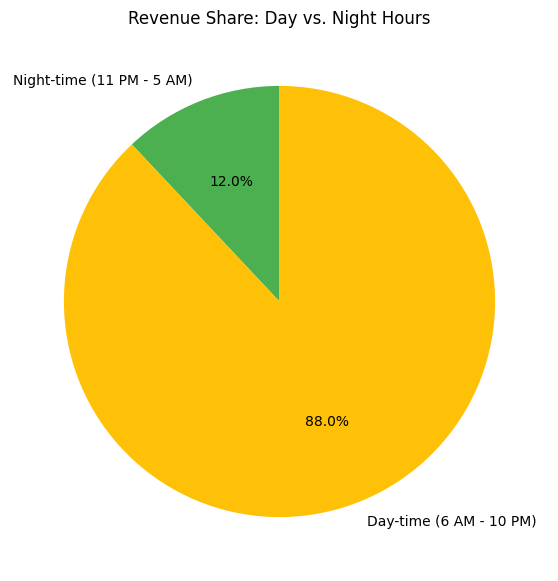

In [ ]:
# Filter for night hours (11 PM to 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))
night_time_revenue = df_financial[df_financial['pickup_hour'].isin(night_hours)]['total_amount'].sum()

# Filter for day hours (6 AM to 10 PM)
day_hours = [hour for hour in range(24) if hour not in night_hours]
day_time_revenue = df_financial[df_financial['pickup_hour'].isin(day_hours)]['total_amount'].sum()

total_revenue = df_financial['total_amount'].sum()

print(f"Night-time Revenue (11 PM - 5 AM): ${night_time_revenue:,.2f}")
print(f"Day-time Revenue (6 AM - 10 PM): ${day_time_revenue:,.2f}")
print(f"Total Revenue: ${total_revenue:,.2f}")

# Calculate percentages
night_time_percentage = (night_time_revenue / total_revenue) * 100
day_time_percentage = (day_time_revenue / total_revenue) * 100

print(f"\nNight-time Revenue Share: {night_time_percentage:.2f}%")
print(f"Day-time Revenue Share: {day_time_percentage:.2f}%")

# Optional: Visualize revenue share
revenue_shares = pd.Series({
    'Night-time (11 PM - 5 AM)': night_time_revenue,
    'Day-time (6 AM - 10 PM)': day_time_revenue
})

plt.figure(figsize=(7, 7))
plt.pie(revenue_shares, labels=revenue_shares.index, autopct='%1.1f%%', colors=['#4CAF50', '#FFC107'], startangle=90)
plt.title('Revenue Share: Day vs. Night Hours')
plt.show()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

Average Fare per Mile per Passenger for different Passenger Counts:


,passenger_count,fare_per_mile_per_passenger
0,1.0,10.908394
1,2.0,6.432401
2,3.0,3.908099
3,4.0,4.363227
4,5.0,1.709614
5,6.0,1.350744


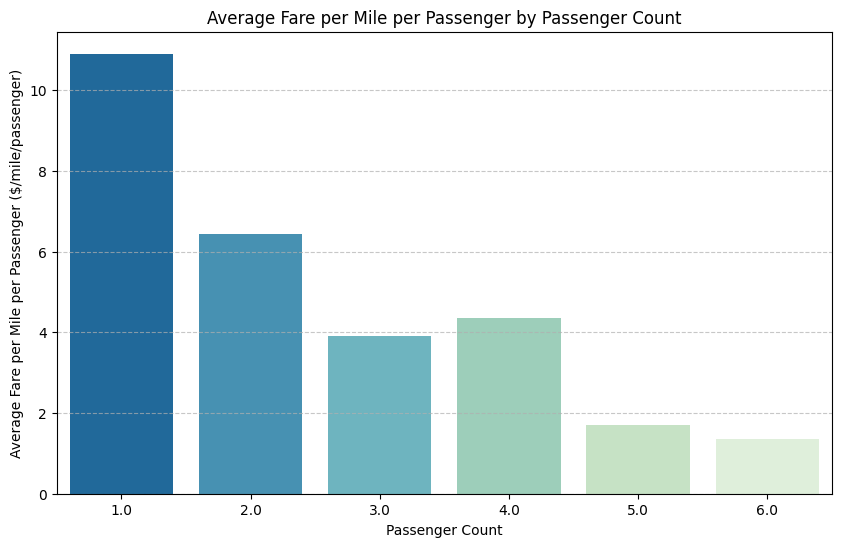

In [ ]:
# Analyze the fare per mile per passenger for different passenger counts

# Filter out trips with zero trip_distance or zero passenger_count to avoid division by zero
df_fare_analysis = df_financial[(df_financial['trip_distance'] > 0) & (df_financial['passenger_count'] > 0)].copy()

# Calculate fare per mile
df_fare_analysis['fare_per_mile'] = df_fare_analysis['fare_amount'] / df_fare_analysis['trip_distance']

# Calculate fare per mile per passenger
df_fare_analysis['fare_per_mile_per_passenger'] = df_fare_analysis['fare_per_mile'] / df_fare_analysis['passenger_count']

# Group by passenger_count and calculate the average fare per mile per passenger
average_fare_per_mile_per_passenger = df_fare_analysis.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

print("Average Fare per Mile per Passenger for different Passenger Counts:")
display(average_fare_per_mile_per_passenger)

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(x='passenger_count', y='fare_per_mile_per_passenger', data=average_fare_per_mile_per_passenger, palette='GnBu_r')
plt.title('Average Fare per Mile per Passenger by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Fare per Mile per Passenger ($/mile/passenger)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

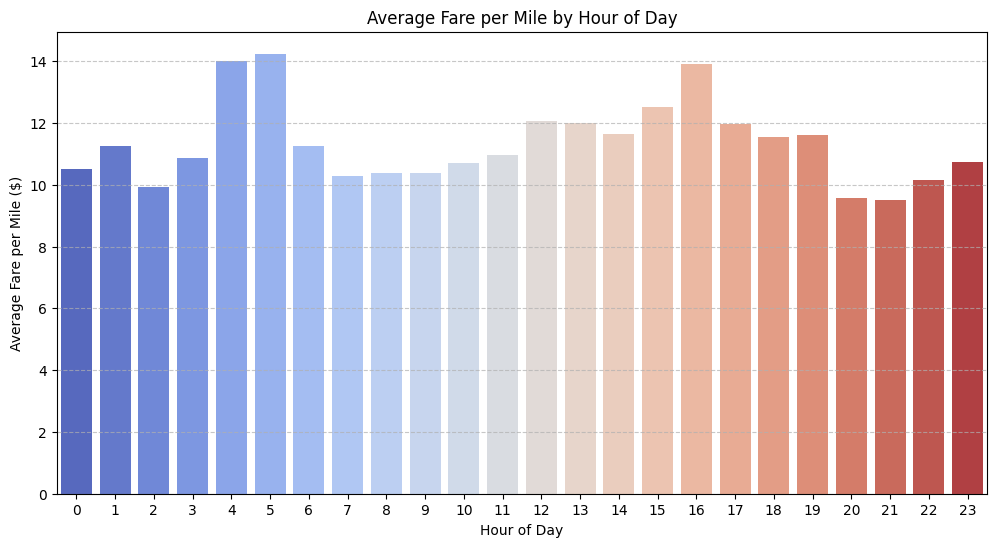

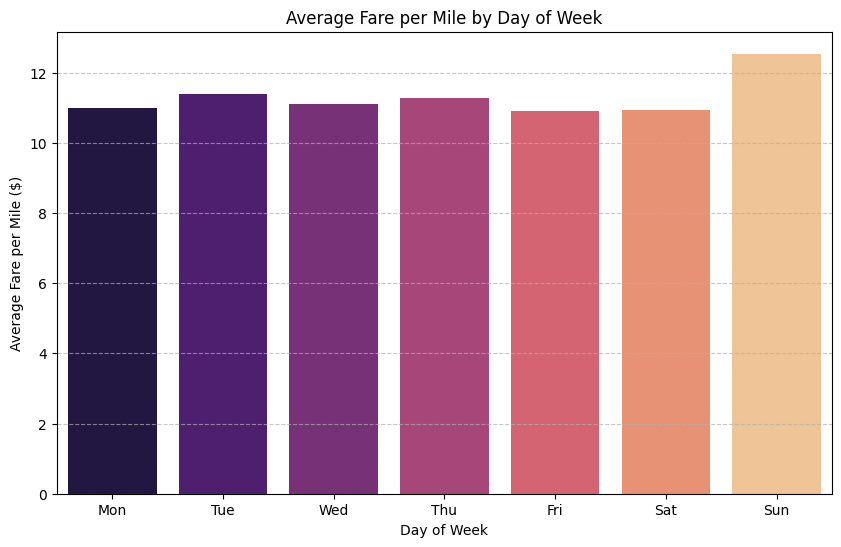

Average Fare per Mile by Hour of Day:


,pickup_hour,fare_per_mile
0,0,10.525939
1,1,11.266999
2,2,9.942036
3,3,10.870866
4,4,14.004000
5,5,14.241165
6,6,11.255591
7,7,10.286871
8,8,10.392698
9,9,10.393025



Average Fare per Mile by Day of Week:


,pickup_day_of_week,fare_per_mile
0,0,10.992922
1,1,11.388626
2,2,11.114081
3,3,11.269755
4,4,10.906043
5,5,10.924954
6,6,12.538107


In [ ]:
# Compare the average fare per mile for different days and for different times of the day

# Filter out trips with zero trip_distance to avoid division by zero
df_fare_per_mile = df_financial[df_financial['trip_distance'] > 0].copy()

# Calculate fare per mile
df_fare_per_mile['fare_per_mile'] = df_fare_per_mile['fare_amount'] / df_fare_per_mile['trip_distance']

# Average fare per mile by hour of the day
average_fare_per_mile_hourly = df_fare_per_mile.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='pickup_hour', y='fare_per_mile', data=average_fare_per_mile_hourly, palette='coolwarm')
plt.title('Average Fare per Mile by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(24))
plt.show()

# Average fare per mile by day of the week
# Ensure 'pickup_day_of_week' exists, create if not (Monday=0, Sunday=6)
if 'pickup_day_of_week' not in df_fare_per_mile.columns:
    df_fare_per_mile['pickup_day_of_week'] = df_fare_per_mile['tpep_pickup_datetime'].dt.dayofweek

average_fare_per_mile_daily = df_fare_per_mile.groupby('pickup_day_of_week')['fare_per_mile'].mean().reset_index()

day_names_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(10, 6))
sns.barplot(x='pickup_day_of_week', y='fare_per_mile', data=average_fare_per_mile_daily, palette='magma')
plt.title('Average Fare per Mile by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Fare per Mile ($)')
plt.xticks(ticks=range(7), labels=day_names_short, rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Fare per Mile by Hour of Day:")
display(average_fare_per_mile_hourly)

print("\nAverage Fare per Mile by Day of Week:")
display(average_fare_per_mile_daily)

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

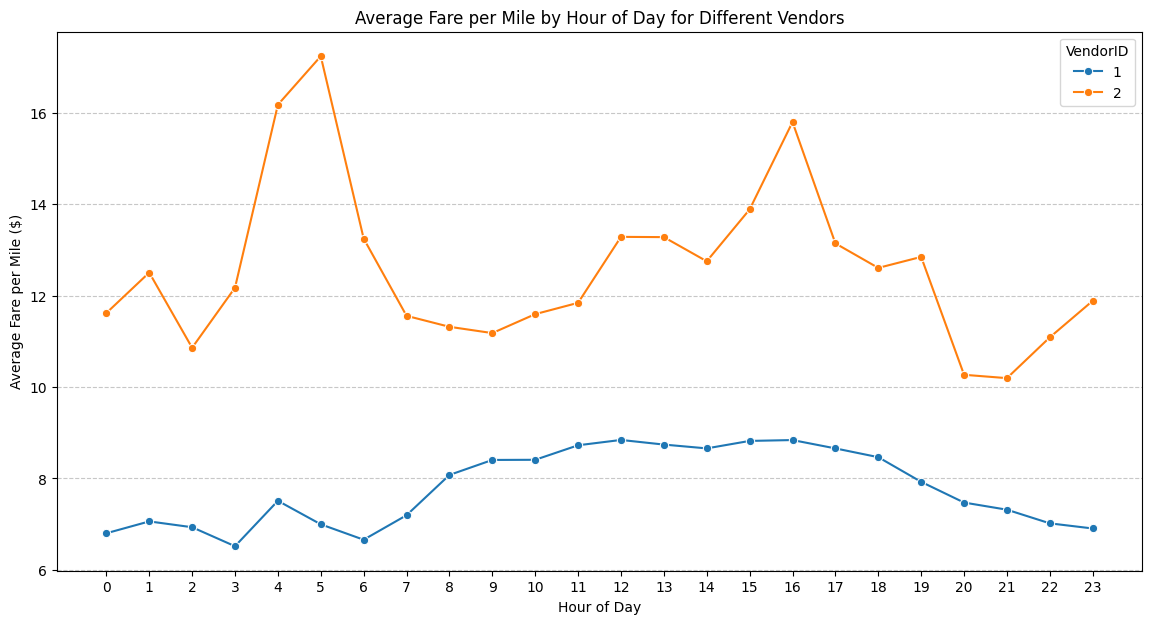

Average Fare per Mile by Hour of Day for Different Vendors:


,VendorID,pickup_hour,fare_per_mile
0,1,0,6.800453
1,1,1,7.059818
2,1,2,6.932493
3,1,3,6.516771
4,1,4,7.510611
5,1,5,6.996239
6,1,6,6.658978
7,1,7,7.194756
8,1,8,8.076387
9,1,9,8.404947


In [ ]:
# Compare fare per mile for different vendors

# Group by VendorID and pickup_hour to calculate average fare per mile
average_fare_per_mile_vendor_hourly = df_fare_per_mile.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='pickup_hour', y='fare_per_mile', hue='VendorID', data=average_fare_per_mile_vendor_hourly, palette='tab10', marker='o')
plt.title('Average Fare per Mile by Hour of Day for Different Vendors')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile ($)')
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='VendorID')
plt.show()

print("Average Fare per Mile by Hour of Day for Different Vendors:")
display(average_fare_per_mile_vendor_hourly)

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


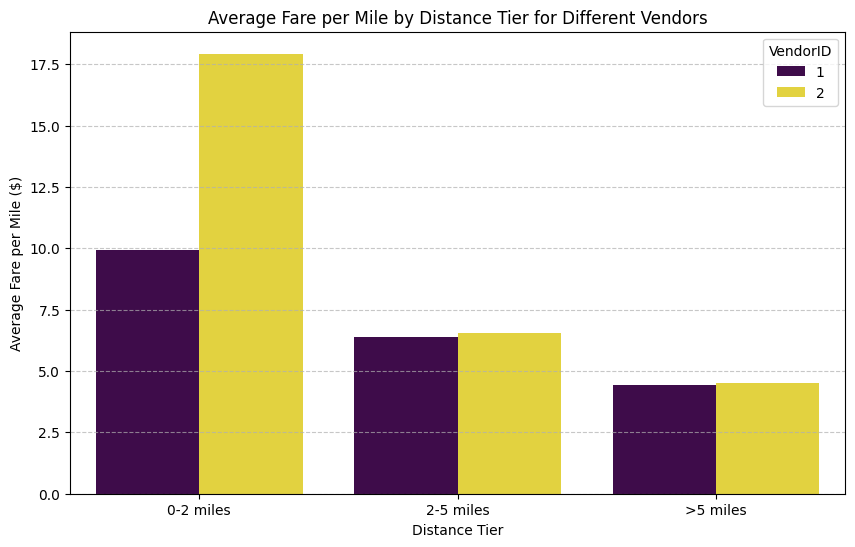

Average Fare per Mile by Distance Tier for Different Vendors:


,VendorID,distance_tier,fare_per_mile
0,1,0-2 miles,9.929365
3,2,0-2 miles,17.929401
1,1,2-5 miles,6.381262
4,2,2-5 miles,6.549258
2,1,>5 miles,4.425249
5,2,>5 miles,4.503240


In [ ]:
# Defining distance tiers

def define_distance_tier(distance):
    if distance <= 2:
        return '0-2 miles'
    elif 2 < distance <= 5:
        return '2-5 miles'
    else:
        return '>5 miles'

df_fare_per_mile['distance_tier'] = df_fare_per_mile['trip_distance'].apply(define_distance_tier)

# Group by VendorID and distance_tier to calculate average fare per mile
average_fare_per_mile_tiered = df_fare_per_mile.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().reset_index()

# Order the distance tiers for better visualization
distance_tier_order = ['0-2 miles', '2-5 miles', '>5 miles']
average_fare_per_mile_tiered['distance_tier'] = pd.Categorical(average_fare_per_mile_tiered['distance_tier'], categories=distance_tier_order, ordered=True);
average_fare_per_mile_tiered = average_fare_per_mile_tiered.sort_values('distance_tier')

plt.figure(figsize=(10, 6))
sns.barplot(x='distance_tier', y='fare_per_mile', hue='VendorID', data=average_fare_per_mile_tiered, palette='viridis')
plt.title('Average Fare per Mile by Distance Tier for Different Vendors')
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare per Mile ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='VendorID')
plt.show()

print("Average Fare per Mile by Distance Tier for Different Vendors:")
display(average_fare_per_mile_tiered)

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times



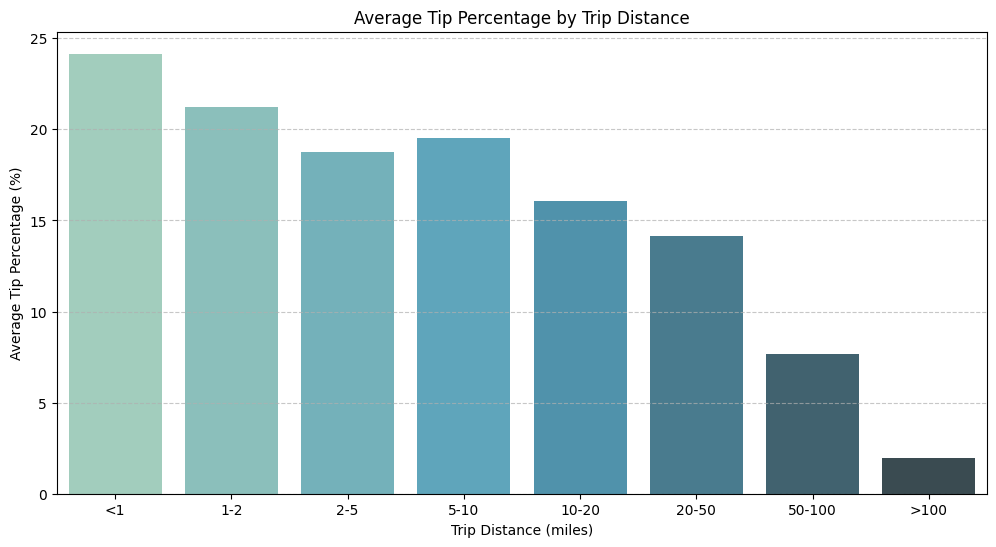

Average Tip Percentage by Trip Distance:


,distance_bin,tip_percentage
0,<1,24.151100
1,1-2,21.231218
2,2-5,18.766539
3,5-10,19.530137
4,10-20,16.053740
5,20-50,14.158836
6,50-100,7.654163
7,>100,1.967131


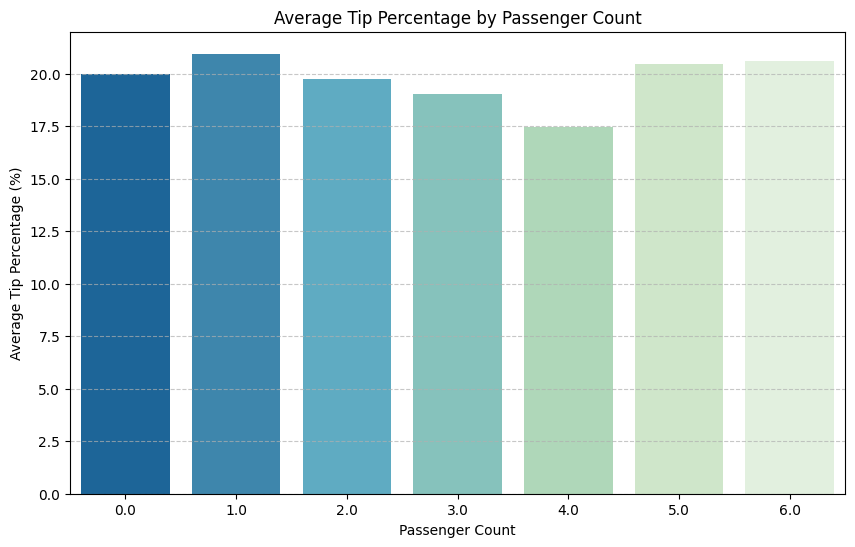


Average Tip Percentage by Passenger Count:


,passenger_count,tip_percentage
0,0.0,19.995697
1,1.0,20.957038
2,2.0,19.730991
3,3.0,19.027261
4,4.0,17.455545
5,5.0,20.490034
6,6.0,20.602040


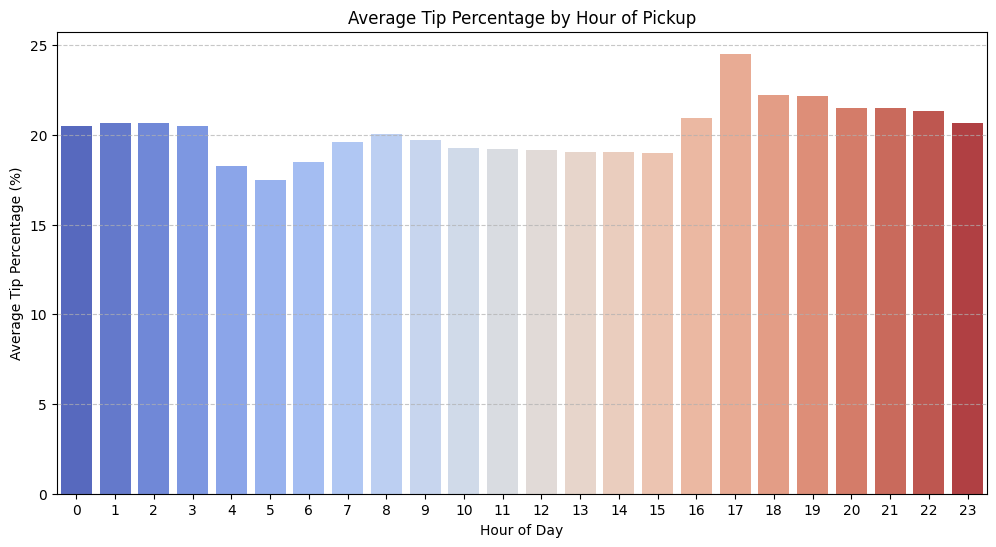


Average Tip Percentage by Hour of Pickup:


,pickup_hour,tip_percentage
0,0,20.502418
1,1,20.663966
2,2,20.651999
3,3,20.512864
4,4,18.250806
5,5,17.485191
6,6,18.466711
7,7,19.605626
8,8,20.047148
9,9,19.707017


In [ ]:
# Ensure 'tip_percentage' is calculated for analysis, handling cases where fare_amount is zero
df_financial['tip_percentage'] = df_financial.apply(
    lambda row: (row['tip_amount'] / row['fare_amount']) * 100 if row['fare_amount'] > 0 else 0,
    axis=1
)

# --- Analysis by Trip Distance ---
# Bin trip distances for better visualization
df_financial['distance_bin'] = pd.cut(df_financial['trip_distance'],
                                      bins=[0, 1, 2, 5, 10, 20, 50, 100, np.inf],
                                      labels=['<1', '1-2', '2-5', '5-10', '10-20', '20-50', '50-100', '>100'])

avg_tip_by_distance = df_financial.groupby('distance_bin')['tip_percentage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='distance_bin', y='tip_percentage', data=avg_tip_by_distance, palette='GnBu_d')
plt.title('Average Tip Percentage by Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Average Tip Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Tip Percentage by Trip Distance:")
display(avg_tip_by_distance)

# --- Analysis by Passenger Count ---
avg_tip_by_passenger_count = df_financial.groupby('passenger_count')['tip_percentage'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='passenger_count', y='tip_percentage', data=avg_tip_by_passenger_count, palette='GnBu_r')
plt.title('Average Tip Percentage by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Tip Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAverage Tip Percentage by Passenger Count:")
display(avg_tip_by_passenger_count)

# --- Analysis by Time of Pickup (Hour) ---
avg_tip_by_hour = df_financial.groupby('pickup_hour')['tip_percentage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='pickup_hour', y='tip_percentage', data=avg_tip_by_hour, palette='coolwarm')
plt.title('Average Tip Percentage by Hour of Pickup')
plt.xlabel('Hour of Day')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAverage Tip Percentage by Hour of Pickup:")
display(avg_tip_by_hour)

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

Characteristics of Low Tips (Tip Percentage < 10%):


,trip_distance,passenger_count,pickup_hour,fare_amount,tip_amount,payment_type
count,471075.000000,471075.000000,471075.000000,471075.000000,471075.000000,471075.000000
mean,3.920414,1.412614,13.934577,21.581766,0.271279,1.764182
std,5.203399,0.930009,5.726459,20.970270,0.865590,0.603747
min,0.010000,0.000000,0.000000,0.010000,0.000000,1.000000
25%,1.080000,1.000000,10.000000,9.300000,0.000000,1.000000
50%,1.900000,1.000000,14.000000,14.200000,0.000000,2.000000
75%,4.020000,2.000000,18.000000,24.700000,0.000000,2.000000
max,204.860000,6.000000,23.000000,1375.000000,30.000000,4.000000



Characteristics of High Tips (Tip Percentage > 25%):


,trip_distance,passenger_count,pickup_hour,fare_amount,tip_amount,payment_type
count,813398.000000,813398.000000,813398.000000,813398.000000,813398.000000,813398.000000
mean,2.301147,1.348090,14.608664,14.414329,4.424849,1.000069
std,2.904228,0.876834,5.812007,11.637411,3.695370,0.012544
min,0.010000,0.000000,0.000000,0.010000,0.870000,1.000000
25%,0.930000,1.000000,11.000000,7.900000,2.700000,1.000000
50%,1.430000,1.000000,16.000000,11.400000,3.360000,1.000000
75%,2.230000,1.000000,19.000000,14.900000,4.450000,1.000000
max,72.280000,6.000000,23.000000,367.000000,223.080000,4.000000


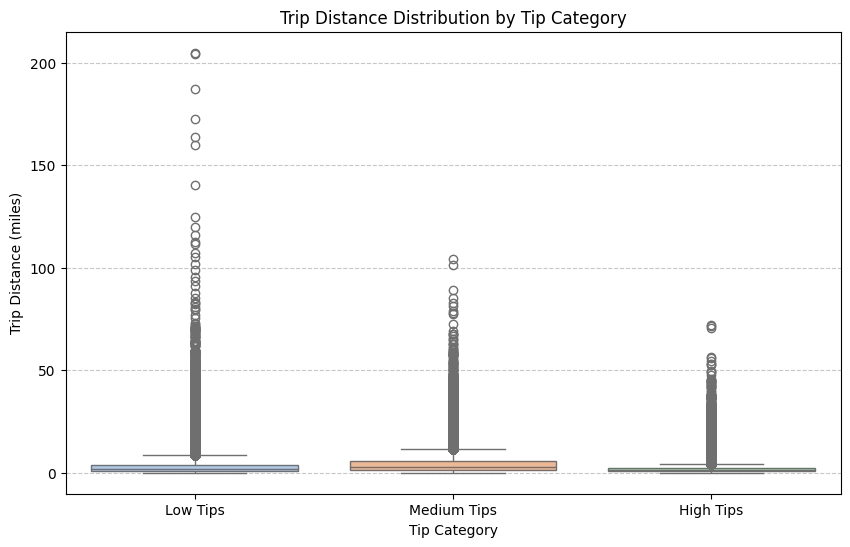

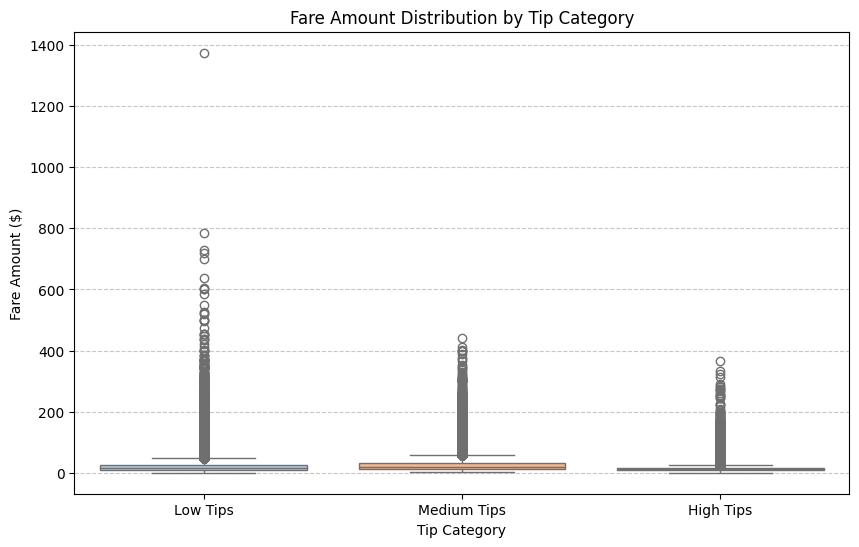


Payment Type Distribution for Low Tips:
payment_type
2    65.761928
1    30.205594
4     2.591307
3     1.441172
Name: proportion, dtype: float64

Payment Type Distribution for High Tips:
payment_type
1    99.996189
2     0.002090
4     0.001352
3     0.000369
Name: proportion, dtype: float64


In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# Define low and high tip thresholds
low_tip_threshold = 10
high_tip_threshold = 25

# Create categories for tip percentages
df_financial['tip_category'] = 'Medium Tips'
df_financial.loc[df_financial['tip_percentage'] < low_tip_threshold, 'tip_category'] = 'Low Tips'
df_financial.loc[df_financial['tip_percentage'] > high_tip_threshold, 'tip_category'] = 'High Tips'

# Analyze characteristics of Low Tips vs. High Tips
print("Characteristics of Low Tips (Tip Percentage < 10%):")
display(df_financial[df_financial['tip_category'] == 'Low Tips'][['trip_distance', 'passenger_count', 'pickup_hour', 'fare_amount', 'tip_amount', 'payment_type']].describe())

print("\nCharacteristics of High Tips (Tip Percentage > 25%):")
display(df_financial[df_financial['tip_category'] == 'High Tips'][['trip_distance', 'passenger_count', 'pickup_hour', 'fare_amount', 'tip_amount', 'payment_type']].describe())

# Visualize average trip distance by tip category
plt.figure(figsize=(10, 6))
sns.boxplot(x='tip_category', y='trip_distance', data=df_financial, palette='pastel')
plt.title('Trip Distance Distribution by Tip Category')
plt.xlabel('Tip Category')
plt.ylabel('Trip Distance (miles)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize average fare amount by tip category
plt.figure(figsize=(10, 6))
sns.boxplot(x='tip_category', y='fare_amount', data=df_financial, palette='pastel')
plt.title('Fare Amount Distribution by Tip Category')
plt.xlabel('Tip Category')
plt.ylabel('Fare Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Payment type distribution for low vs. high tips
low_tip_payment_dist = df_financial[df_financial['tip_category'] == 'Low Tips']['payment_type'].value_counts(normalize=True) * 100
high_tip_payment_dist = df_financial[df_financial['tip_category'] == 'High Tips']['payment_type'].value_counts(normalize=True) * 100

print("\nPayment Type Distribution for Low Tips:")
print(low_tip_payment_dist)
print("\nPayment Type Distribution for High Tips:")
print(high_tip_payment_dist)

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

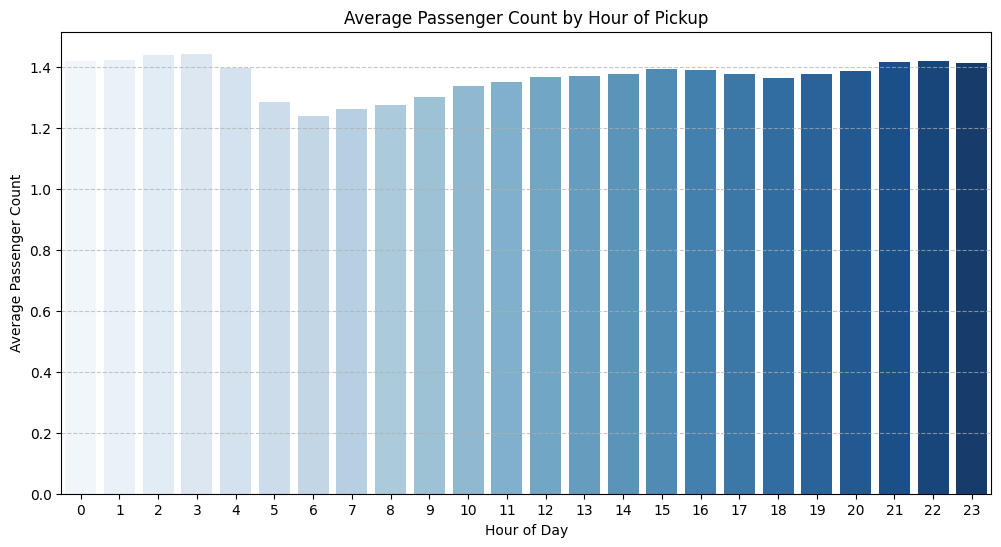

Average Passenger Count by Hour of Pickup:


,pickup_hour,passenger_count
0,0,1.417516
1,1,1.422183
2,2,1.436966
3,3,1.442265
4,4,1.396301
5,5,1.283217
6,6,1.239584
7,7,1.260017
8,8,1.275651
9,9,1.299405


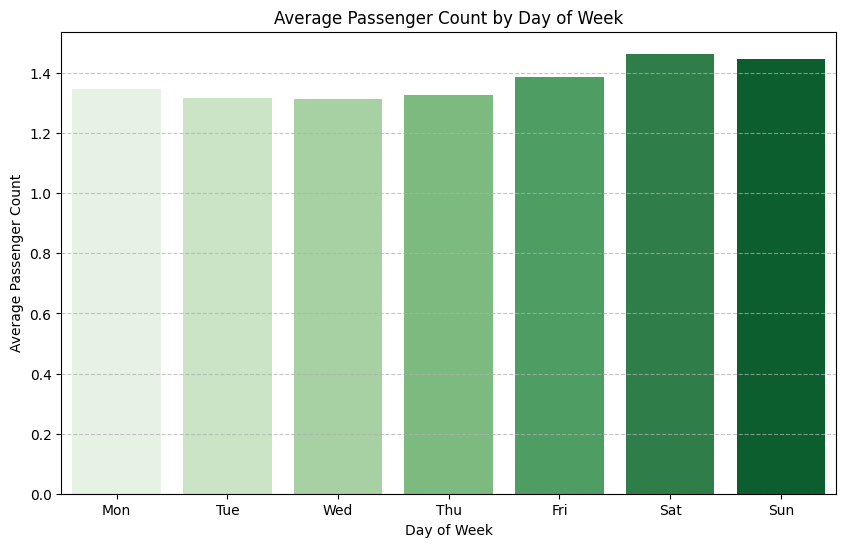


Average Passenger Count by Day of Week:


,pickup_day_of_week,passenger_count
0,0,1.346382
1,1,1.318325
2,2,1.314313
3,3,1.328296
4,4,1.385289
5,5,1.464021
6,6,1.448023


In [ ]:
# See how passenger count varies across hours and days

# Average passenger count by hour of the day
avg_passenger_count_hourly = df_financial.groupby('pickup_hour')['passenger_count'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='pickup_hour', y='passenger_count', data=avg_passenger_count_hourly, palette='Blues')
plt.title('Average Passenger Count by Hour of Pickup')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passenger Count')
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Passenger Count by Hour of Pickup:")
display(avg_passenger_count_hourly)

# Average passenger count by day of the week
# Ensure 'pickup_day_of_week' exists, create if not (Monday=0, Sunday=6)
if 'pickup_day_of_week' not in df_financial.columns:
    df_financial['pickup_day_of_week'] = df_financial['tpep_pickup_datetime'].dt.dayofweek

avg_passenger_count_daily = df_financial.groupby('pickup_day_of_week')['passenger_count'].mean().reset_index()

day_names_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(10, 6))
sns.barplot(x='pickup_day_of_week', y='passenger_count', data=avg_passenger_count_daily, palette='Greens')
plt.title('Average Passenger Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Passenger Count')
plt.xticks(ticks=range(7), labels=day_names_short, rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAverage Passenger Count by Day of Week:")
display(avg_passenger_count_daily)

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones



In [ ]:
avg_passenger_count_per_zone = df_financial.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_passenger_count_per_zone.rename(columns={'PULocationID': 'LocationID', 'passenger_count': 'average_passenger_count'}, inplace=True)

# Merge with zones GeoDataFrame
zones_with_avg_passengers = pd.merge(zones, avg_passenger_count_per_zone, on='LocationID', how='left')
zones_with_avg_passengers['average_passenger_count'] = zones_with_avg_passengers['average_passenger_count'].fillna(0) # Fill NaN for zones with no pickups

print("Zones with highest average passenger count:")
display(zones_with_avg_passengers.sort_values(by='average_passenger_count', ascending=False).head())

print("\nZones with lowest (non-zero) average passenger count:")
display(zones_with_avg_passengers[zones_with_avg_passengers['average_passenger_count'] > 0].sort_values(by='average_passenger_count').head())

Zones with highest average passenger count:


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,average_passenger_count
5,6,0.150491,0.000606,Arrochar/Fort Wadsworth,6,Staten Island,"POLYGON ((966568.747 158679.855, 966615.256 15...",1.954545
194,195,0.131308,0.000802,Red Hook,195,Brooklyn,"POLYGON ((982261.185 189334.878, 982725.423 18...",1.817204
11,12,0.036661,0.000042,Battery Park,12,Manhattan,"POLYGON ((979908.772 196066.565, 979980.852 19...",1.725707
206,207,0.028376,0.000045,Saint Michaels Cemetery/Woodside,207,Queens,"POLYGON ((1011571.962 216050.175, 1011545.889 ...",1.666667
57,58,0.059855,0.000205,Country Club,58,Bronx,"POLYGON ((1035263.069 248349.465, 1035243.096 ...",1.666667



Zones with lowest (non-zero) average passenger count:


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,average_passenger_count
31,32,0.054267,0.000151,Bronxdale,32,Bronx,"POLYGON ((1023302.25 251923.918, 1022481.96 25...",0.975610
209,210,0.114852,0.000453,Sheepshead Bay,210,Brooklyn,"POLYGON ((1004356.905 156081.405, 1004653.331 ...",0.982143
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",1.000000
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",1.000000
30,31,0.096425,0.000334,Bronx Park,31,Bronx,"POLYGON ((1019950.154 251628.997, 1019950.288 ...",1.000000


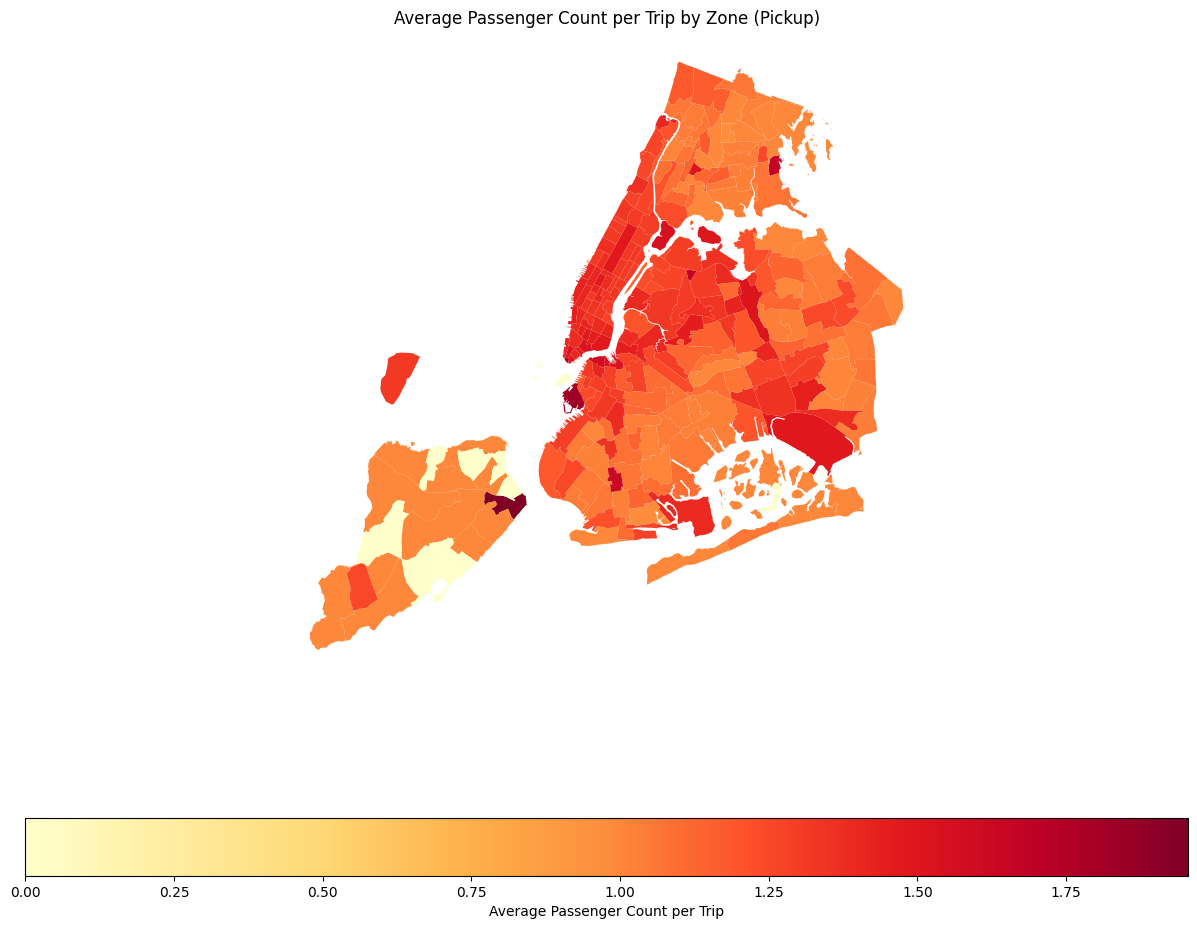

In [ ]:
# Visualize average passenger count by zone
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

zones_with_avg_passengers.plot(
    column='average_passenger_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd', # Colormap for average passenger count
    legend_kwds={'label': 'Average Passenger Count per Trip', 'orientation': 'horizontal'}
)
ax.set_title('Average Passenger Count per Trip by Zone (Pickup)')
ax.set_axis_off()
plt.show()

Next, let's look into the prevalence of extra charges and surcharges. Understanding when and where these are applied can help in optimizing pricing and transparency.

In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Prevalence of Surcharges and Extra Charges:
- extra: 1126882 trips (62.32% of total trips)
- mta_tax: 1796756 trips (99.37% of total trips)
- improvement_surcharge: 1808104 trips (100.00% of total trips)
- congestion_surcharge: 1680267 trips (92.93% of total trips)
- Airport_fee_updated: 158798 trips (8.78% of total trips)


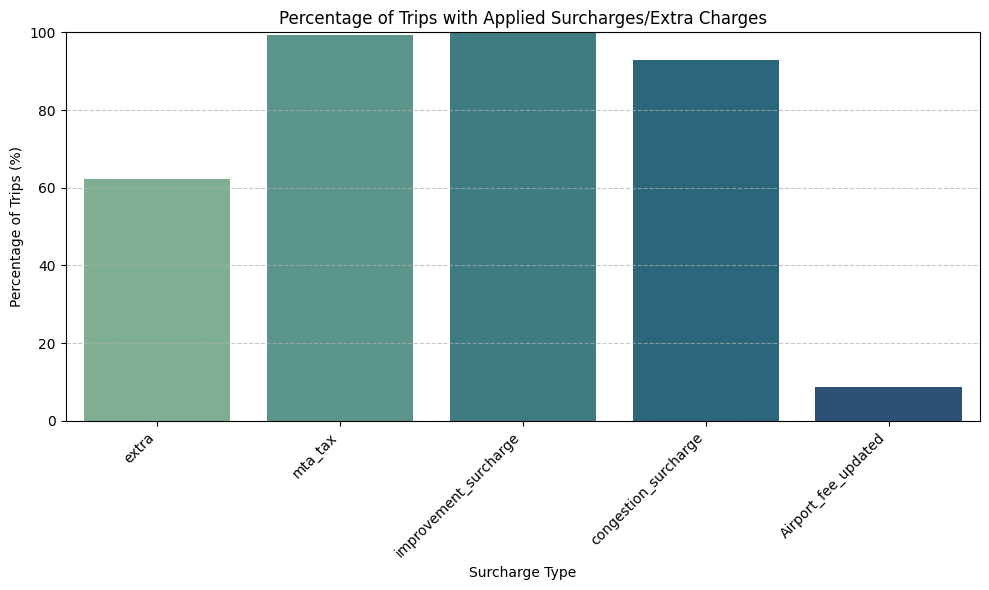

In [ ]:
# Define the surcharge columns to analyze
surcharge_columns = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee_updated']

print("Prevalence of Surcharges and Extra Charges:")
for col in surcharge_columns:
    # Count trips where the surcharge/extra is applied (value > 0)
    applied_count = (df_financial[col] > 0).sum()
    total_trips = len(df_financial)

    if total_trips > 0:
        percentage_applied = (applied_count / total_trips) * 100
        print(f"- {col}: {applied_count} trips ({percentage_applied:.2f}% of total trips)")
    else:
        print(f"- {col}: No trips in the filtered DataFrame to analyze.")

# For better visual comparison, create a bar plot of these percentages
surcharge_prevalence = pd.DataFrame({
    'Surcharge': surcharge_columns,
    'Percentage_Applied': [(df_financial[col] > 0).sum() / len(df_financial) * 100 for col in surcharge_columns]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Surcharge', y='Percentage_Applied', data=surcharge_prevalence, palette='crest')
plt.title('Percentage of Trips with Applied Surcharges/Extra Charges')
plt.xlabel('Surcharge Type')
plt.ylabel('Percentage of Trips (%)')
plt.ylim(0, 100) # Ensure y-axis is from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**Recommendations:**
1.  **Dynamic Dispatching for Peak Hours/Zones:** Implement a dynamic dispatching system that proactively positions cabs in high-demand zones (Midtown, Upper East Side, Airports) during peak hours (5-7 PM weekdays) to minimize waiting times and maximize trip efficiency.
2.  **Congestion-Aware Routing:** Integrate real-time traffic data and historical slowest routes into the routing algorithm. For known slow routes or areas, suggest alternative routes or reroute cabs to avoid chronic congestion points, especially during peak times.
3.  **Targeted Driver Incentives:** Offer incentives for drivers to operate in or through traditionally slow routes during off-peak hours, or to take less congested alternative routes during peak hours, to distribute demand and improve overall fleet speed.
4.  **Dedicated Airport Fleet:** Given the high traffic at JFK and LaGuardia, consider having a dedicated or incentivized fleet for airport runs to ensure consistent service and faster turnaround, reducing potential bottlenecks in the general city fleet.
5.  **Utilize Pickup/Dropoff Ratios:** For zones with high pickup-to-dropoff ratios (e.g., JFK Airport 4.91), drivers often return empty. Implement algorithms to match incoming drop-offs to these zones with waiting pickups, or use these zones as strategic staging areas. Conversely, for zones with high dropoff-to-pickup ratios, drivers should be advised to quickly move to nearby high-pickup zones.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**Recommendations:**
1.  **Time-Based Pre-positioning:**
    *   **Morning Rush (6-9 AM):** Position cabs near residential areas with high commuter density or public transport hubs.
    *   **Lunch/Mid-day (12-2 PM):** Focus on business districts and commercial areas.
    *   **Evening Peak (5-8 PM):** Heavily concentrate cabs in central business districts, entertainment venues, and major transportation hubs (like Grand Central, Penn Station) where pickups are highest.
    *   **Late Night (11 PM-3 AM):** Shift focus to entertainment districts, bar/restaurant areas, and night-time hotspots identified (e.g., East Village, West Village) as well as airports for late-night arrivals.
2.  **Day-of-Week Adjustments:**
    *   **Weekdays (Tue-Fri):** Maintain high fleet density in business and commercial zones throughout the day.
    *   **Weekends (Sat-Sun):** Reposition more cabs towards tourist attractions, shopping districts, and residential areas during the day, and entertainment hubs at night.
3.  **Leverage Zone Ratios:** Use the calculated pickup/dropoff ratios to guide repositioning. Zones with high `pickup_dropoff_ratio` (more pickups than dropoffs) are good locations for drivers to head *towards* after a drop-off. Zones with low ratios (more drop-offs than pick-ups) suggest drivers should *leave* these zones quickly to find new fares.
4.  **Heatmap-Based Deployment:** Develop real-time demand heatmaps based on historical data and current activity. Dispatchers and drivers can use these to identify areas with high potential for immediate pickups.
5.  **Event-Based Positioning:** Incorporate public event calendars (concerts, sports, festivals) to anticipate temporary demand surges in specific zones and pre-position vehicles accordingly.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

1. Dynamic Pricing for Peak Demand: Implement surge pricing during peak hours (5-7 PM weekdays, early mornings 4-5 AM) and days (Sundays) to maximize revenue.
2. Competitive Tiered Pricing: Analyze VendorID 2's higher fare per mile to understand if service improvements can justify similar pricing for VendorID 1. Continue decreasing fare per mile for longer distance tiers.
3. Multi-Passenger Fare Adjustments: Review the fare per mile per passenger model; consider a slight increase for additional passengers or a dynamic 'group' rate to optimize vehicle utilization and revenue.
4. Transparency in Surcharges: Clearly communicate all applicable surcharges upfront to enhance customer trust.
5. Off-Peak Incentives: Offer minor discounts or loyalty bonuses during quieter hours (e.g., late evening weekdays) to stimulate demand and maintain driver activity.